# Bitcoin Supply Dynamics

### How much bitcoin is dormant, and how much dormancy is ending

Bitcoin's supply schedule is the most famous fixed quantity in finance. Twenty-one million coins, a halving every four years, an issuance curve written down in 2008 and unchanged since. It is genuinely fixed and genuinely predictable. The age structure of that stock is a separate, measurable question.

Each year miners now create well under 200,000 new coins. In the same year, millions of coins that had sat untouched for a year or more move — many times the new issuance, as section 11 measures for the latest complete year. Every one of those coins sat in an output that was spent. Not all of it changed hands — section 2 is about why — but all of it stopped being dormant.

So the supply question that matters is not *how many coins exist*. It is:

> **How much of the existing stock is sitting dormant, and how much dormancy is ending?**

That question has an answer at the UTXO level, and this notebook builds the measurements from the ground up. It does not equate on-chain movement with coins offered for sale or with market liquidity.

We start with what the protocol gives us and work outward.

---

*Data: [BRK](https://bitview.space) on-chain metrics, from the [Bitcoin Report Library](https://github.com/SecretSatoshis/Bitcoin-Report-Library). See [Data sources and terms](#Data-sources-and-terms) at the end.*

## Setup

One cell of plumbing before we start, so the rest of the notebook is about bitcoin rather than about code.

The data comes from the repository's supply and demand release in `data/research/`, built and validated from the Bitcoin Report Library before this notebook runs. Here we confirm the saved files match it and set up chart styling.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# scripts/update_data.py builds and validates the release; this notebook only reads it.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src/bitcoin_investment_strategy").is_dir()), None)
if ROOT is None:
    raise ValueError("Run this notebook from the repository or its notebooks directory")
DATA_FILE = ROOT / "data/research/bitcoin_daily.csv"
DATA_MANIFEST_PATH = ROOT / "data/research/manifests/data_manifest.json"
import sys
sys.path.insert(0, str(ROOT / "src"))
from bitcoin_investment_strategy.research.analysis import (
    apply_research_theme, BLUE, RED, GREEN, GREY, ORANGE, PRIMARY, AGE_PALETTE,
    BRK, covered_periods, validate_cohorts, compact, thousands,
    period_centers, price_axis, finish, release_age_note, halving_dates,
)
from bitcoin_investment_strategy.io import verify_artifacts
from bitcoin_investment_strategy.savings import prepare_prices
data_manifest = json.loads(DATA_MANIFEST_PATH.read_text())
verify_artifacts(data_manifest, ROOT, [DATA_FILE])

print(f"Release {data_manifest['release_id']}")
age_note = release_age_note(data_manifest["core_data_end"])
if age_note:
    print(age_note)

# The Secret Satoshis dark chart theme and brand palette, shared with the demand notebook.
apply_research_theme()

# ------------------------------------------------------- chart helpers
# Shared helpers (compact, period_centers, price_axis, finish) live in
# bitcoin_investment_strategy.research.analysis so both notebooks format charts the same way.
def millions(x, _):  return f"{x/1e6:,.1f}M"


# Age bands are ordered, so their colors run in order too, cool to warm (AGE_PALETTE,
# from bitcoin_investment_strategy.research.analysis).
BAND_ORDER = ["1-2y", "2-3y", "3-4y", "4-5y", "5-10y", "10y+"]
BAND_COLORS = dict(zip(BAND_ORDER, AGE_PALETTE))

# The cumulative thresholds use the same progression, so color means the same
# thing -- depth in the age ladder -- on every chart in the notebook.
COHORT_COLORS = dict(zip(["1y", "2y", "3y", "4y", "5y", "10y"], AGE_PALETTE))


print("Ready.")

Release 2026-10-04-0ca2c90befdd
Ready.


## The series we pull

Twenty-eight daily series, all from the Bitcoin Report Library's release, and it is worth seeing the shape of the list before the values arrive. They fall into five groups, and each group answers a different question.

| Group | Series | The question it answers |
|---|---|---|
| **Protocol** | `supply`, `subsidy_cumulative` | How many coins exist and how many are being created |
| **Age cohorts** | `utxos_over_{1,2,3,4,5,10}y_old_supply` and their transfer volume | How much supply has sat untouched, and what happens when it moves? |
| **UTXO split** | `lth_*`, `sth_*` | The same questions across BRK's 150-day long-term / short-term division |
| **Valuation** | `price_close`, `realized_cap`, `realized_price`, `mvrv`, `supply_in_profit` | How does market price compare with UTXO creation-price proxies? |
| **Dormancy** | `coindays_destroyed_cumulative` | When coins move, how long had they been still? |

Two conventions matter. Everything is a **completed-day** series: the current UTC day is excluded because it can still change. Stocks are sampled directly. Flows — coins moved, output-level profit and loss, coin-days destroyed and coins mined — are published as cumulative series and first-differenced into non-overlapping daily intervals before aggregation. BRK's `_sum_24h` fields are rolling windows, so they are deliberately not used here.

In [2]:
COHORTS = ["1y", "2y", "3y", "4y", "5y", "10y"]

protocol = ["supply", "subsidy_cumulative"]
valuation = ["price_close", "realized_cap", "realized_price", "mvrv", "supply_in_profit"]
dormancy = ["coindays_destroyed_cumulative"]

holder = ["lth_supply", "sth_supply",
          "lth_realized_price", "sth_realized_price",
          "lth_realized_profit_cumulative", "lth_realized_loss_cumulative",
          "sth_realized_profit_cumulative", "sth_realized_loss_cumulative"]

cohort_supply = [f"utxos_over_{a}_old_supply" for a in COHORTS]
cohort_spent  = [f"utxos_over_{a}_old_transfer_volume_cumulative" for a in COHORTS]

ALL_SERIES = list(dict.fromkeys(
    protocol + valuation + dormancy + holder
    + cohort_supply + cohort_spent))

shared = pd.read_csv(DATA_FILE, parse_dates=["date"]).set_index("date").sort_index()
source = pd.DataFrame(index=shared.index)
for name in ALL_SERIES:
    canonical = "price" if name == "price_close" else name
    if canonical not in shared:
        raise ValueError(f"bitcoin_daily.csv is missing {canonical}")
    source[name] = shared[canonical]
print(f"Loaded {len(ALL_SERIES)} BRK series from {DATA_FILE.relative_to(ROOT)}")

FLOW_SERIES = {
    "subsidy_daily": "subsidy_cumulative",
    "coindays_destroyed_daily": "coindays_destroyed_cumulative",
    "lth_realized_profit_daily": "lth_realized_profit_cumulative",
    "lth_realized_loss_daily": "lth_realized_loss_cumulative",
    "sth_realized_profit_daily": "sth_realized_profit_cumulative",
    "sth_realized_loss_daily": "sth_realized_loss_cumulative",
    **{f"utxos_over_{a}_old_transfer_volume_daily":
       f"utxos_over_{a}_old_transfer_volume_cumulative" for a in COHORTS},
}


# The release already carries each flow as the daily difference of its cumulative
# series (bitcoin_investment_strategy.research.transforms). Read those rather than
# re-deriving them here, so the notebook cannot drift from the release it verifies.
raw = source.drop(columns=list(FLOW_SERIES.values())).copy()
for daily_name in FLOW_SERIES:
    if daily_name not in shared:
        raise ValueError(f"bitcoin_daily.csv is missing flow {daily_name}")
    raw[daily_name] = shared[daily_name]
raw = raw.sort_index()
print(f"\n{raw.shape[0]:,} rows x {raw.shape[1]} series")

Loaded 28 BRK series from data/research/bitcoin_daily.csv

6,121 rows x 28 series


### One check before we use any of it

Two quirks in this data will quietly ruin any calculation built on top of them, and both are easy to see once you look.

**Bitcoin had no price for its first nineteen months.** No exchange existed, so the release, which starts on 1 January 2010, leaves `price_close` blank until August 2010 rather than recording a zero, which would turn anything divided by price into infinity. Every priced calculation therefore starts at the first market price.

**A cohort cannot exist before the chain is old enough.** There were no coins older than ten years until January 2019, so `utxos_over_10y_old_supply` is exactly `0.0` for the first decade. That is a real zero, not a gap, and treating it as "no old coins are being held" rather than "this question has no answer yet" would be wrong.

Both are handled the same way: find the first date the data can actually answer the question, and start there.

In [3]:
def validate(df):
    """Start the analysis at the first market price.

    The release checks already guarantee every series runs gap-free to the same last day,
    so the only trim left is the period before bitcoin had a price.
    """
    first_price = prepare_prices(df["price_close"]).index[0]
    print(f"  dropped {int((df.index < first_price).sum())} days before bitcoin had a market price")
    df = df.loc[first_price:]
    print(f"  usable history: {df.index.min().date()} to {df.index.max().date()} ({len(df):,} days)")
    return df


print("Validating:")
daily = validate(raw)

print("\nWhen each age cohort first had any coins in it:")
for a in COHORTS:
    col = f"utxos_over_{a}_old_supply"
    # Cohort formation predates the priced/validated frame, so inspect the
    # untrimmed stock series rather than silently anchoring 1y+ to first price.
    first = (raw[col] > 0).idxmax()
    print(f"  {a + '+':>4}  {first.date()}")

FIRST_DAY, LAST_DAY = daily.index.min(), daily.index.max()


def complete_periods(idx, freq, first=None, last=None):
    """True where a resampled period is fully covered by the data.

    Both ends matter. Checking only that a period ends before the last day of
    data marks the FIRST period complete even when the data starts partway
    through it — which would treat 138 days of 2010 as a full year.

    The bounds default to the validated frame, and are arguments because
    section 1 works off the untrimmed record instead. The coverage rule itself
    is shared with the demand notebook (bitcoin_investment_strategy.research.analysis).
    """
    first = FIRST_DAY if first is None else first
    last = LAST_DAY if last is None else last
    return pd.Series(covered_periods(idx, freq, first, last), index=idx)

Validating:
  dropped 227 days before bitcoin had a market price
  usable history: 2010-08-16 to 2026-10-04 (5,894 days)

When each age cohort first had any coins in it:
   1y+  2010-01-09
   2y+  2011-01-09
   3y+  2012-01-09
   4y+  2013-01-08
   5y+  2014-01-08
  10y+  2019-01-07


---

# 1. The supply that is created

We start with the part everyone knows — every block pays its miner a subsidy. The subsidy halves roughly every four years, and that is the entire mechanism by which new bitcoin comes into existence. The curve below is the result: steep at the start, flattening toward an asymptote a little under 21 million.

The second panel is the one worth dwelling on. It counts coins created per calendar year, and the halvings arrive as cliffs. In 2010 miners created roughly 3.4 million coins; the output below gives the latest complete year, a small fraction of that against a stock several times larger.

New issuance has become a trickle next to what already exists. Everything from here is about the other twenty million coins — the existing UTXO set, how long it has remained still and when outputs move.

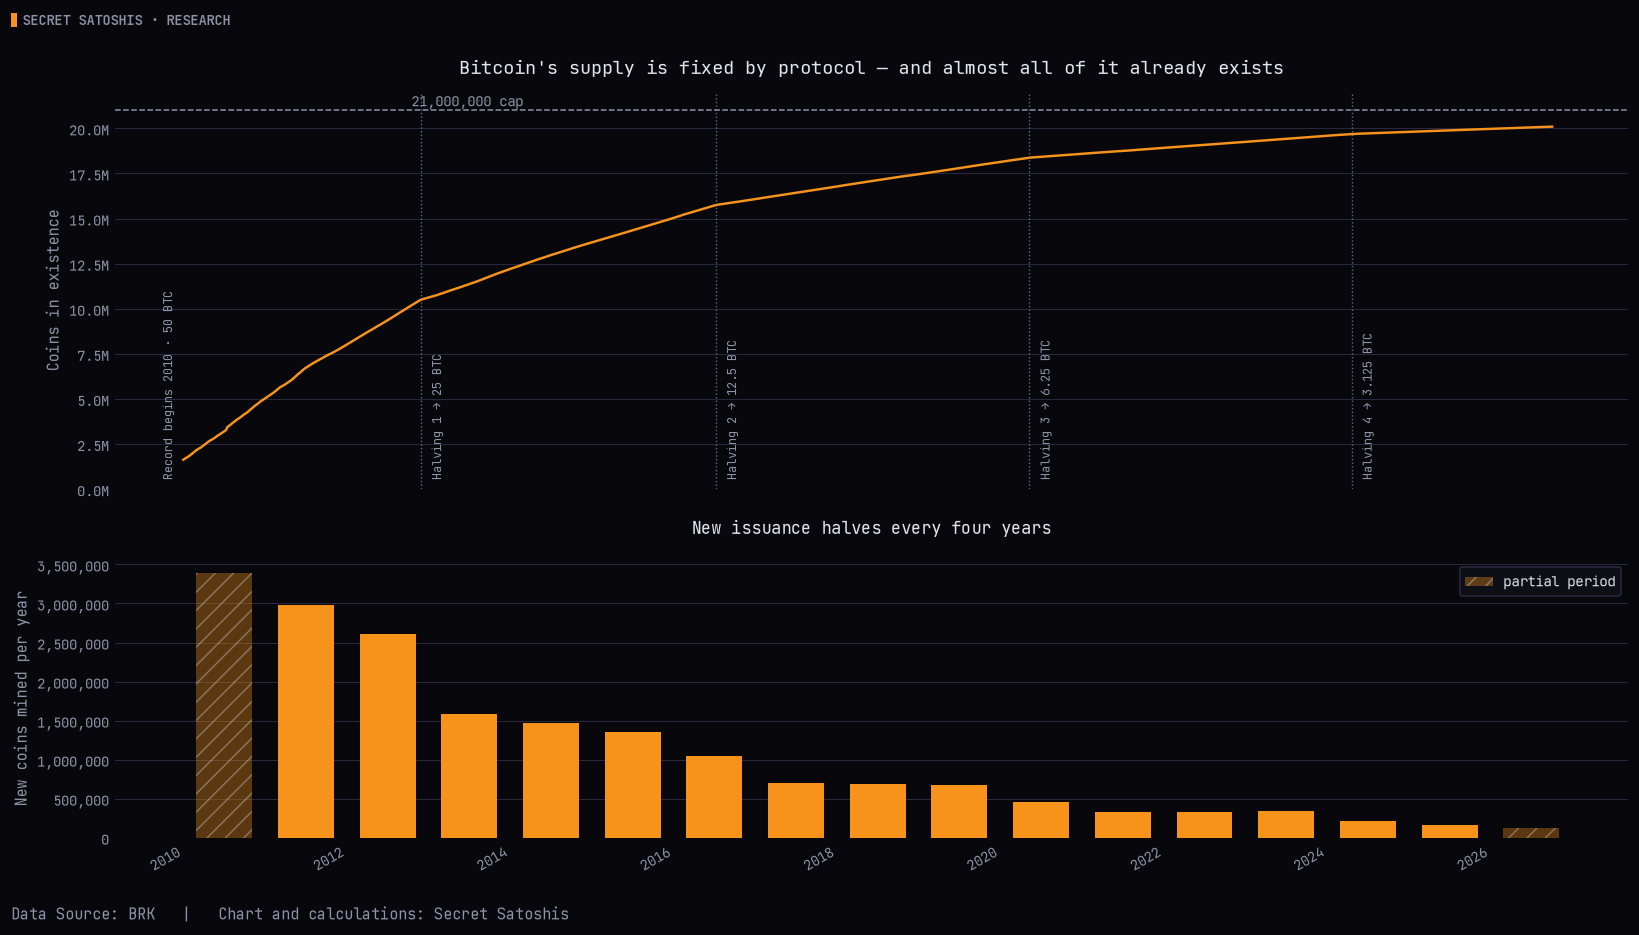

Coins mined in 2011:    2,981,350
Coins mined in 2025:      165,881
Total supply at latest completed day:   20,093,282

Last full year's issuance was 0.83% of all coins in existence.


In [4]:
# Nothing here is priced, so this is the one place the untrimmed record is safe
# to use: `validate` cuts the months before bitcoin's first market price, and
# issuance does not care whether a market existed. The record starts in 2010,
# a year after the genesis block.
created = raw.loc[:LAST_DAY, ["supply", "subsidy_daily"]]
GENESIS = created.index.min()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8.5), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1.4]})

ax1.plot(created.index, created["supply"], color=ORANGE, linewidth=1.6)
ax1.axhline(21e6, color=GREY, linestyle="--", linewidth=1)
ax1.annotate("21,000,000 cap", (created.index[len(created)//6], 21e6), fontsize=9,
             color=GREY, va="bottom")

# Halving dates are the protocol schedule (bitcoin_investment_strategy.research.analysis),
# shared with the demand notebook and the Report Library.
halvings = halving_dates()


def reward_label(ax, x, text, side=1):
    """Rotated marker text, kept short enough to sit in the empty space under the supply
    curve; side=-1 puts it left of `x`."""
    ax.annotate(text, xy=(x, 0), xytext=(5 * side, 6), textcoords="offset points", rotation=90,
                fontsize=8, color=GREY, ha="left" if side > 0 else "right", va="bottom")


# The curve starts at the record's first day, so this label sits to its left.
reward_label(ax1, GENESIS, f"Record begins {GENESIS.year} · 50 BTC", side=-1)
for n, date, reward in halvings:
    ax1.axvline(date, color=GREY, linestyle=":", linewidth=.9, alpha=.7)
    reward_label(ax1, date, f"Halving {n} → {reward:g} BTC")

ax1.set_ylabel("Coins in existence"); ax1.set_ylim(0, 22e6)
ax1.yaxis.set_major_formatter(FuncFormatter(millions))
ax1.set_title("Bitcoin's supply is fixed by protocol — and almost all of it already exists",
              fontsize=12, pad=12)

# Coins created per calendar year. The first and last years are partial, so they
# are drawn differently rather than being compared against complete years.
issuance = created["subsidy_daily"].resample("YE").sum(min_count=1)
# Each day's issuance is a difference from the day before, so it starts a day after the record.
complete = complete_periods(issuance.index, "Y", first=created["subsidy_daily"].first_valid_index()).values

# Resampling stamps each year at its last day, and a bar drawn there straddles
# the new year's tick — so every bar would sit half a year right of the year it
# describes. Draw them on the midpoint of the period instead.
years = issuance.index.to_period("Y")
centers = years.start_time + (years.end_time - years.start_time) / 2

ax2.bar(centers[complete], issuance[complete], width=250, color=ORANGE)
ax2.bar(centers[~complete], issuance[~complete], width=250, color=ORANGE,
        alpha=.35, hatch="//", label="partial period")
ax2.set_ylabel("New coins mined per year")
ax2.yaxis.set_major_formatter(FuncFormatter(thousands))
if (~complete).any(): ax2.legend(fontsize=9)
ax2.set_title("New issuance halves every four years", fontsize=11)
finish(fig, sources=[BRK])

first_full, last_full = issuance[complete].index[0].year, issuance[complete].index[-1].year
print(f"Coins mined in {first_full}: {issuance[complete].iloc[0]:>12,.0f}")
print(f"Coins mined in {last_full}: {issuance[complete].iloc[-1]:>12,.0f}")
print(f"Total supply at latest completed day: {created['supply'].iloc[-1]:>12,.0f}")
print(f"\nLast full year's issuance was {issuance[complete].iloc[-1]/created['supply'].iloc[-1]*100:.2f}% "
      "of all coins in existence.")

---

# 2. Coins have an age — and "spent" is a slippery word

Bitcoin does not have accounts with balances. It has **unspent transaction outputs** — discrete chunks of coin, each stamped with the moment it was created. That stamp is what makes everything here possible: for any coin, at any time, we can ask *how long has this sat untouched?*

When a UTXO is consumed in a transaction it is **spent**, and the clock resets — the coin reappears as a new output carrying today's date.

That word is doing more work than it looks like it is.

**"Spent" means a UTXO was consumed. Nothing more.** It does not mean sold. It does not mean the owner changed. An exchange consolidating wallets, a custodian rotating keys, someone moving coins between their own hardware wallets — on-chain, all of it looks exactly like a sale.

The same point has a mechanical version, and the volume series in this notebook are built on it. To spend anything you must consume a whole UTXO. Send one coin from a thousand-coin chunk and the transaction consumes all thousand, sends one to the recipient, and returns 999 to you as a brand new output. The `transfer_volume` series record the **input** value, so that transaction registers a thousand coins of movement. All thousand genuinely left the age band — the returned 999 carry today's date now, and their clock starts again. But only one coin changed hands.

So these series measure coins leaving an age band. That is exactly what they claim to measure, and it is not the same thing as coins being offered to the market.

**When does that matter?** Any single large day. A 300,000-coin spike could be one custodian's internal migration, and reading intent into it would be a mistake.

**What aggregation does:** It reduces the influence of a single transaction and reveals persistent re-aging across cohorts. It does not prove operational movement is stable through time or distinguish custody migration from ownership change. Multi-month movement is a more stable description of UTXO turnover, not a direct measure of market supply.

Which is the case the charts below make. Day to day, spending of year-old coins is violently spiky — the busiest day runs far above the median. Widen the window to a week and then a month and that ratio falls sharply (the table below gives the exact figures), and the shape underneath starts to show. Sorting that supply by age is where the shape starts to say something.

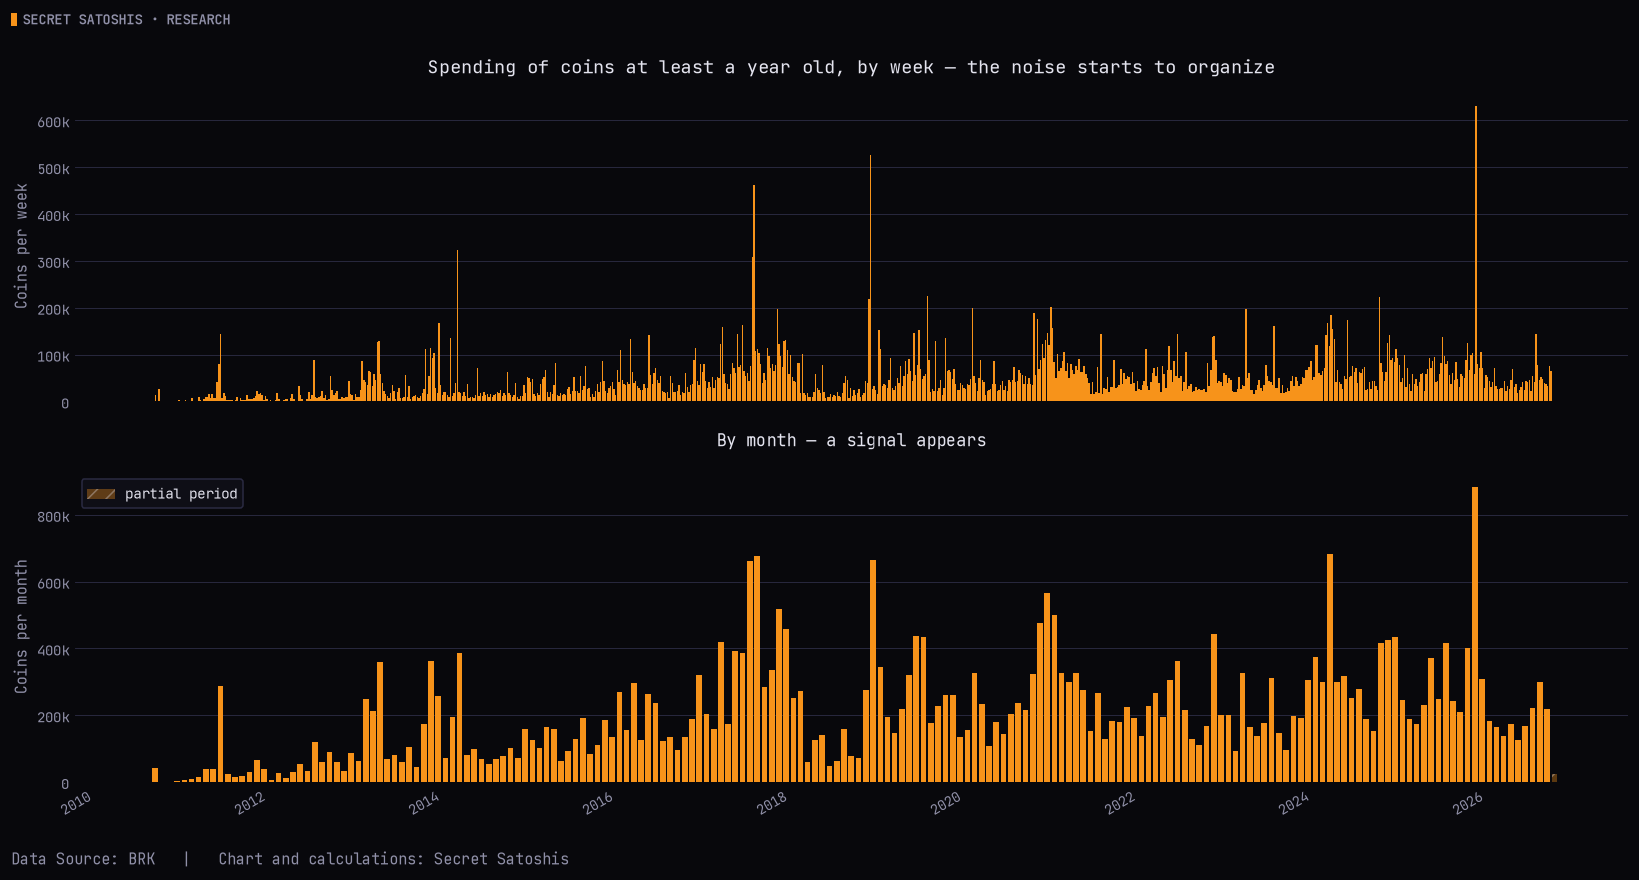

                busiest    median    ratio
Daily           353,314     3,410     104x
Weekly          629,688    36,257      17x
Monthly         883,589   179,951       5x
Quarterly     1,623,279   613,675       3x

A single day tells you almost nothing. A quarter tells you something.


In [5]:
spent_1y = daily["utxos_over_1y_old_transfer_volume_daily"]

# Resample rule, the matching period code, and a bar width in days.
STEPS = [("W", "W", 6, "By week — the noise starts to organize"),
         ("ME", "M", 24, "By month — a signal appears")]


def aggregated(series, rule, code, first=None):
    """Totals per period, plus the midpoint of each period and whether it is full.

    Resampling stamps every period at its last day, so bars drawn on the raw
    index would sit to the right of the span they describe. Both ends of the
    record can also land mid-period, and a partial total is not comparable to
    a full one — so those are returned separately to be drawn differently.
    """
    agg = series.resample(rule).sum(min_count=1)
    centers = period_centers(agg.index, code)
    return agg, centers, complete_periods(agg.index, code,
                                          first=first or series.index.min()).values


fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for ax, (rule, code, width, title) in zip(axes, STEPS):
    agg, centers, full = aggregated(spent_1y, rule, code)
    ax.bar(centers[full], agg[full], width=width, color=ORANGE)
    ax.bar(centers[~full], agg[~full], width=width, color=ORANGE, alpha=.35,
           hatch="//", label="partial period")
    ax.set_ylabel(f"Coins per {'week' if code == 'W' else 'month'}")
    ax.yaxis.set_major_formatter(FuncFormatter(compact))
    ax.set_title(title, fontsize=11)
    if ax is axes[-1] and (~full).any():
        ax.legend(fontsize=9, loc="upper left")

axes[0].set_title("Spending of coins at least a year old, by week — the noise starts to organize",
                  fontsize=12, pad=12)
finish(fig, sources=[BRK])

# Spikiness is what aggregation removes, so measure it the same way at each
# resolution: the loudest period against the typical one, counting only periods
# the data covers in full. The day and the quarter are here as the bookends the
# charts no longer need to show.
print(f"{'':<11}{'busiest':>12}{'median':>10}{'ratio':>9}")
for label, rule, code in (("Daily", "D", "D"), ("Weekly", "W", "W"),
                          ("Monthly", "ME", "M"), ("Quarterly", "QE", "Q")):
    agg, _, full = aggregated(spent_1y, rule, code)
    agg = agg[full]
    print(f"{label:<11}{agg.max():>12,.0f}{agg.median():>10,.0f}{agg.max()/agg.median():>8,.0f}x")

print("\nA single day tells you almost nothing. A quarter tells you something.")

---

# 3. Sorting supply by age

Every coin carries an age, so supply can be sorted by it. That is what the cohort series do: `utxos_over_1y_old_supply` counts the coins that have not moved in at least a year.

**These buckets are cumulative, not exclusive**, and it is the single most common thing to get wrong about them. Coins in the 5-year bucket are also in the 3-year bucket, and the 2-year, and the 1-year. Each threshold contains every threshold above it — they nest like Russian dolls.

To get a band — coins aged *between* two and three years — you subtract:

```
   band(2–3y)  =  supply(2y+)  −  supply(3y+)
```

Because the buckets nest properly, no band comes out negative. Worth checking rather than assuming: a negative band would mean the nesting is broken, and every calculation built on top of it would be wrong.

One thing the buckets cannot tell you: some of the oldest supply is not dormant, it is gone. Coins in wallets whose keys were lost sit in the deepest bands forever and are counted as held. Estimates run to a million coins or more, most of it in the 10-year band — so read the old cohorts as an upper bound on supply that could ever move again.

The first chart is the thresholds, stacked in strict order. The second subtracts them into bands, and that is where the age structure of the UTXO set becomes visible. The bands are the map. What it means when coins move off it is the next question.

  1y+ >= 2y+ on every day: yes
  2y+ >= 3y+ on every day: yes
  3y+ >= 4y+ on every day: yes
  4y+ >= 5y+ on every day: yes
  5y+ >= 10y+ on every day: yes

  every band non-negative: yes (minimum 0.0 coins)


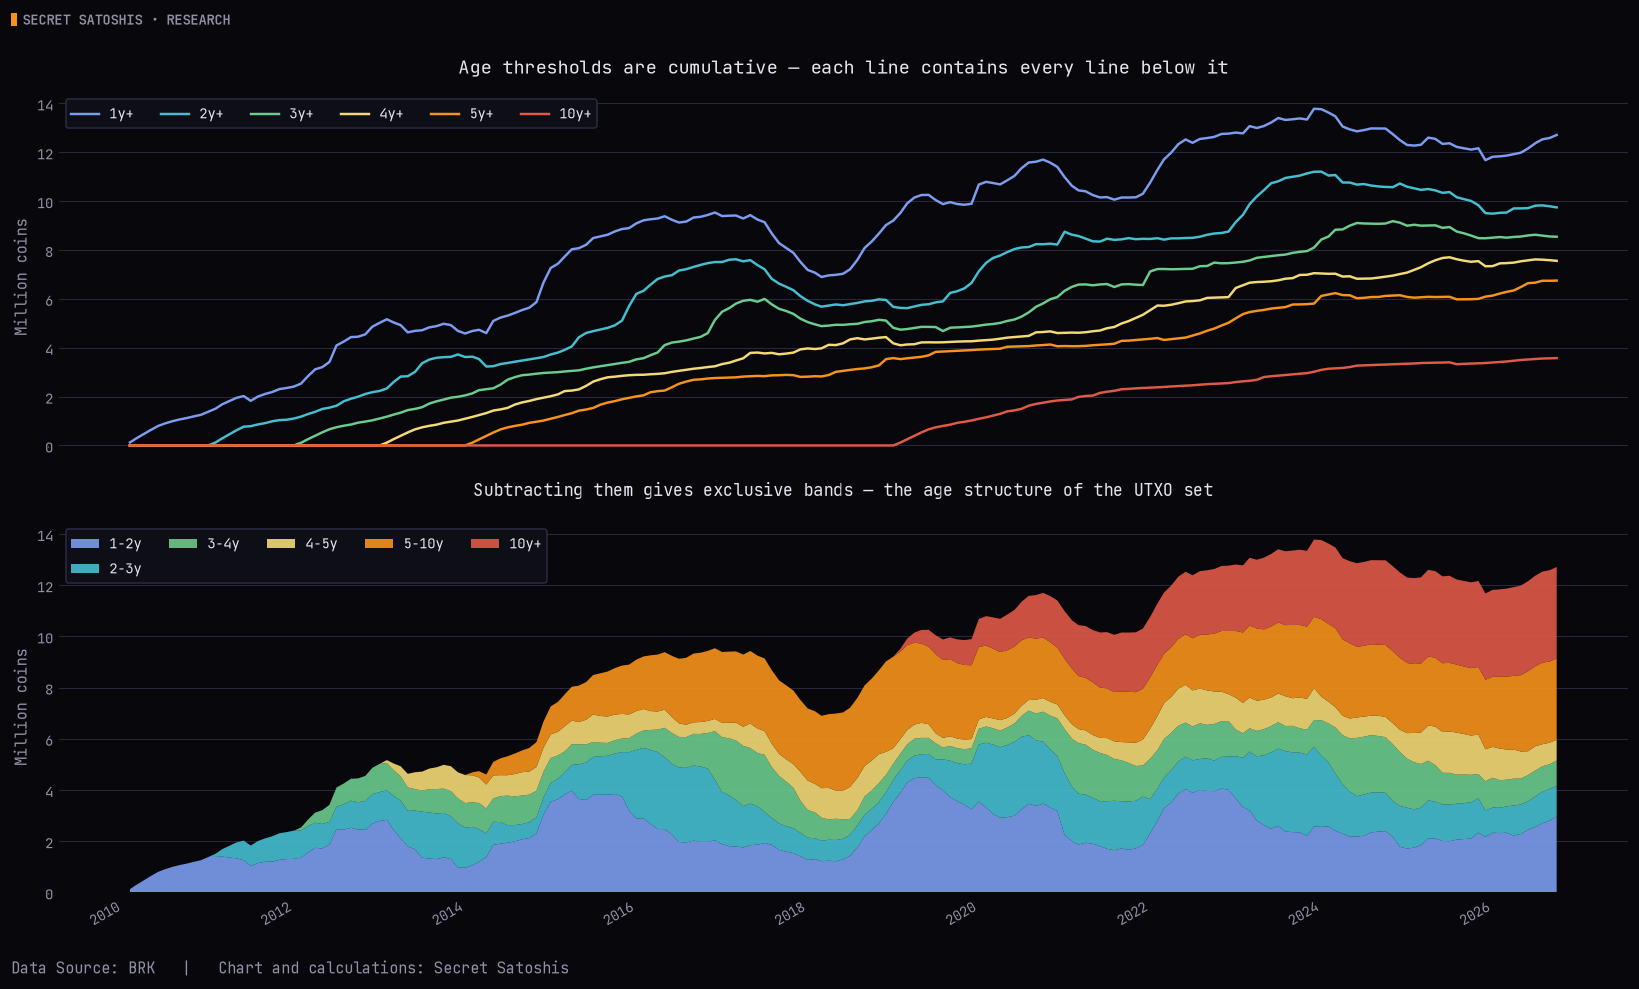

In [6]:
history = raw.loc[:LAST_DAY]
stocks = pd.DataFrame({f"{a}+": history[f"utxos_over_{a}_old_supply"] for a in COHORTS})

# The nesting must hold: each threshold contains the one above it.
violations = 0
for younger, older in zip(COHORTS[:-1], COHORTS[1:]):
    bad = (stocks[f"{younger}+"] < stocks[f"{older}+"] - 1e-6).sum()
    violations += bad
    print(f"  {younger}+ >= {older}+ on every day: {'yes' if bad == 0 else f'NO ({bad} days)'}")
if violations:
    raise ValueError("cohort nesting is broken")


def exclusive_bands(df):
    """Turn nested thresholds into non-overlapping age bands by subtraction.

    Single-year resolution to five years, then a wider band to ten. Coins move
    between adjacent years often enough that a three-to-five year bucket hides
    the direction of travel inside it -- one year draining while the next fills
    nets out to a flat line. Past five years the cohorts are small and slow
    enough that the wider grouping loses nothing.
    """
    out = pd.DataFrame(index=df.index)
    out["1-2y"]  = df["1y+"]  - df["2y+"]
    out["2-3y"]  = df["2y+"]  - df["3y+"]
    out["3-4y"]  = df["3y+"]  - df["4y+"]
    out["4-5y"]  = df["4y+"]  - df["5y+"]
    out["5-10y"] = df["5y+"]  - df["10y+"]
    out["10y+"]  = df["10y+"]
    return out


bands = exclusive_bands(stocks)
if not (bands.min() >= -1e-6).all():
    raise ValueError("a band came out negative")
print(f"\n  every band non-negative: yes (minimum {bands.min().min():.1f} coins)")

m_stocks = stocks.resample("ME").last()
m_bands = bands.resample("ME").last()
m_stocks, m_bands = m_stocks[m_stocks.index <= LAST_DAY], m_bands[m_bands.index <= LAST_DAY]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
for a in COHORTS:
    ax1.plot(m_stocks.index, m_stocks[f"{a}+"] / 1e6, color=COHORT_COLORS[a],
             linewidth=1.6, label=f"{a}+")
ax1.set_ylabel("Million coins"); ax1.legend(ncol=6, fontsize=9)
ax1.set_title("Age thresholds are cumulative — each line contains every line below it",
              fontsize=12, pad=12)

ax2.stackplot(m_bands.index, *[m_bands[c] / 1e6 for c in m_bands.columns],
              labels=list(m_bands.columns),
              colors=[BAND_COLORS[c] for c in m_bands.columns], alpha=.9)
ax2.set_ylabel("Million coins"); ax2.legend(loc="upper left", ncol=5, fontsize=9)
ax2.set_title("Subtracting them gives exclusive bands — the age structure of the UTXO set",
              fontsize=11)
finish(fig, sources=[BRK])

---

# 4. Weighting movement by how long it sat

Counting coins treats every movement alike. Ten coins that last moved yesterday and ten that last moved in 2013 are the same number, and obviously not the same event.

**Coin-days destroyed** fixes that. A coin sitting still for a day accumulates one coin-day. Spend it and the accumulated coin-days are destroyed. Move a coin dormant for a decade and 3,650 coin-days go with it; move one from last week and seven do.

So the measure answers a different question from volume: not *how much moved*, but **how much dormancy ended**. A quiet day with one ancient wallet waking up destroys more coin-days than a frantic day of recent coins churning.

The raw number is hard to compare across time, because it scales with the supply that exists to sit still. The comparable version first divides daily coin-days destroyed by the outstanding supply, then compares a trailing total with the median of same-length windows ending during the preceding year. Above one, more supply-adjusted dormancy ended than in that reference distribution; below one, less.

The same mechanical point from section 2 applies here. Spending is all-or-nothing at the level of an output, so consuming one old UTXO destroys every coin-day it had accumulated, however small the amount being moved. Coin-days destroyed measures dormancy ending, which is exactly what happened; it does not measure how much anyone intended to move.

The chart uses six months as the middle descriptive horizon. The calculation is also reported at predeclared 90-, 180- and 365-day windows so the conclusion can be checked for sensitivity rather than selected from the resulting crossing count or range.

The first chart is the raw monthly series. The second is the supply-adjusted 180-day ratio, and the table underneath shows whether the latest reading survives the two alternative horizons.

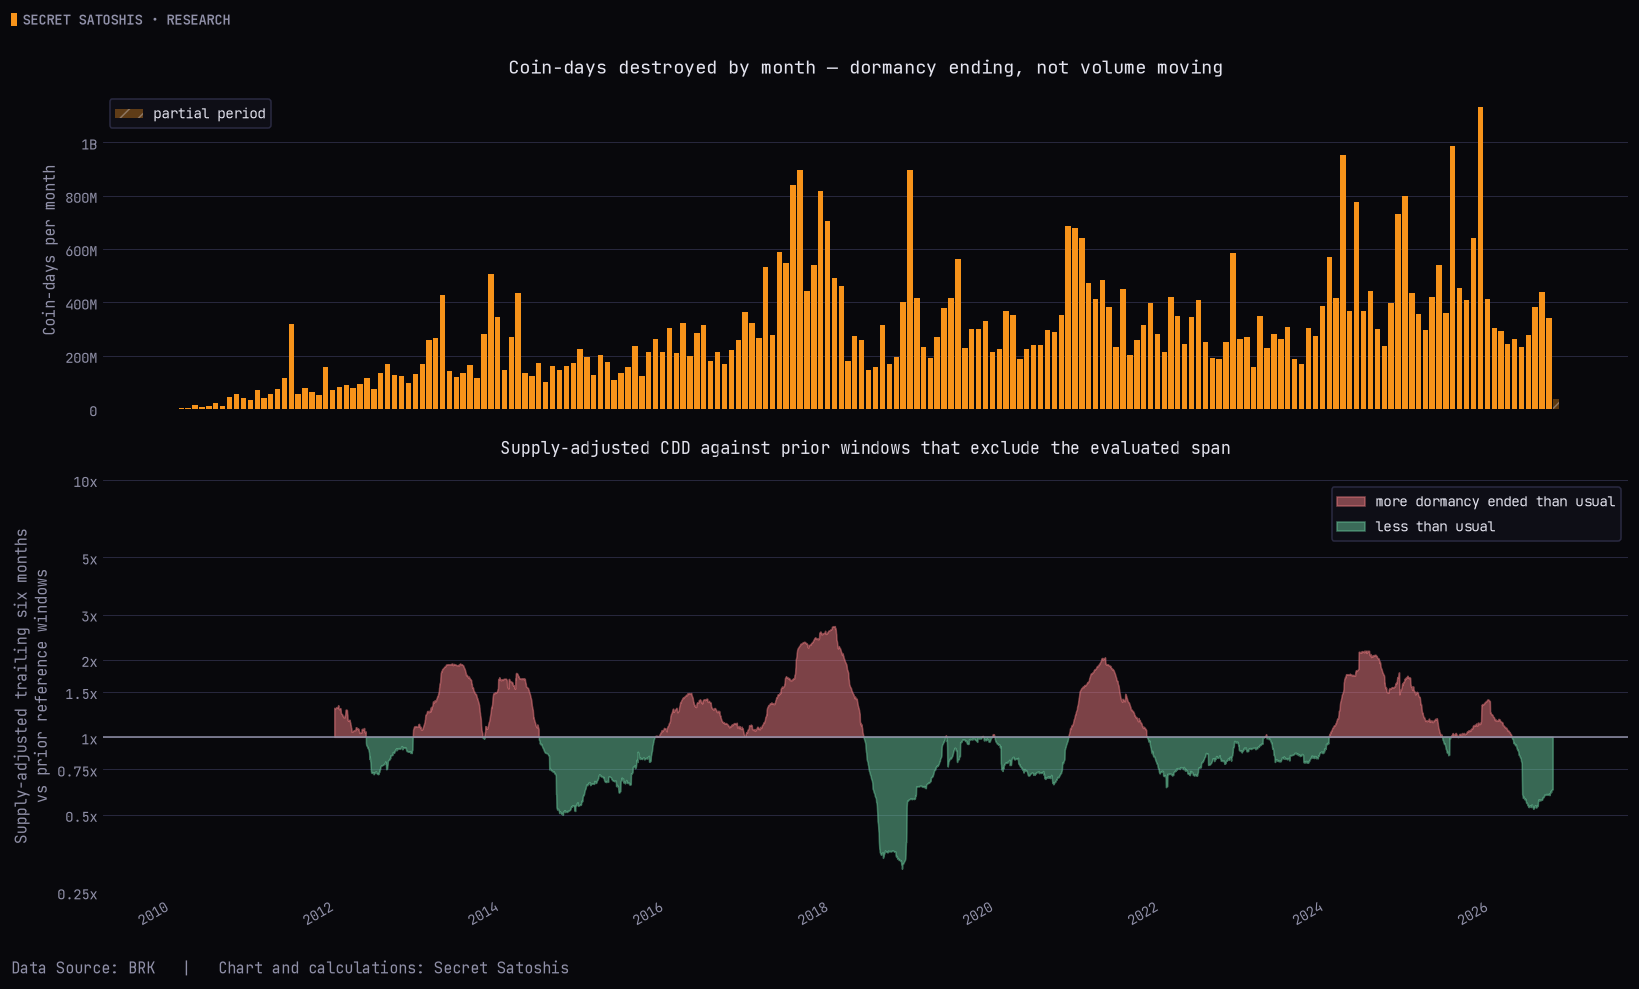

window        latest   percentile    median               range
  90 days      0.71x         15%     1.02x    0.26x to 3.85x
 180 days      0.63x          9%     1.01x    0.31x to 2.69x
 365 days      0.84x         30%     1.10x    0.55x to 2.32x


In [7]:
cdd = raw.loc[:LAST_DAY, "coindays_destroyed_daily"]
cdd_per_coin = cdd / raw.loc[:LAST_DAY, "supply"].replace(0, np.nan)
CDD_START = cdd_per_coin.first_valid_index()


def vs_own_history(series, window, benchmark=365):
    """Trailing total over `window` days, against the typical total before it.

    The benchmark must not contain the window it is judging. Shifting by a day
    would leave the median built from windows sharing all but one day with the
    current one — a spike would raise its own bar. Shifting by the window length
    clears it: the newest window inside the median ends the day before the
    current one begins.
    """
    total = series.rolling(window).sum()
    reference = total.shift(window).rolling(benchmark).median()
    return total / reference.replace(0, np.nan)


SENSITIVITY_WINDOWS, WINDOW, BENCHMARK = (90, 180, 365), 180, 365

# Starts are determined only by the observations required by each calculation:
# one measured window, one non-overlap clearance window and one benchmark year.
ratios = {}
for window in SENSITIVITY_WINDOWS:
    required = 2 * window + BENCHMARK - 2
    start = CDD_START + pd.Timedelta(days=required)
    ratios[window] = vs_own_history(cdd_per_coin, window, BENCHMARK).loc[start:]
ratio = ratios[WINDOW]

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1.3]})

monthly, centers, full = aggregated(cdd, "ME", "M", first=CDD_START)
axes[0].bar(centers[full], monthly[full], width=24, color=ORANGE)
axes[0].bar(centers[~full], monthly[~full], width=24, color=ORANGE, alpha=.35,
            hatch="//", label="partial period")
if (~full).any(): axes[0].legend(fontsize=9, loc="upper left")
axes[0].set_ylabel("Coin-days per month")
axes[0].yaxis.set_major_formatter(FuncFormatter(compact))
axes[0].set_title("Coin-days destroyed by month — dormancy ending, not volume moving",
                  fontsize=12, pad=12)

axes[1].fill_between(ratio.index, 1, ratio, where=ratio >= 1,
                     color=RED, alpha=.5, label="more dormancy ended than usual")
axes[1].fill_between(ratio.index, 1, ratio, where=ratio < 1,
                     color=GREEN, alpha=.5, label="less than usual")
axes[1].axhline(1, color=GREY, linewidth=1)

# Log scale, so a half-rate period sits as far from the line as a double-rate
# one. Ticks are set by hand because the series spends its life inside a single
# decade, where the default log ticks label almost nothing.
axes[1].set_yscale("log"); axes[1].set_ylabel("Supply-adjusted trailing six months\nvs prior reference windows")
axes[1].set_yticks([0.25, 0.5, 0.75, 1, 1.5, 2, 3, 5, 10]); axes[1].minorticks_off()
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}x"))
axes[1].legend(fontsize=9, loc="upper right")
axes[1].set_title("Supply-adjusted CDD against prior windows that exclude the evaluated span", fontsize=11)
finish(fig, sources=[BRK])

print(f"{'window':<10}{'latest':>10}{'percentile':>13}{'median':>10}{'range':>20}")
for window in SENSITIVITY_WINDOWS:
    live = ratios[window].dropna()
    percentile = (live < live.iloc[-1]).mean() * 100
    print(f"{window:>4} days {live.iloc[-1]:>9.2f}x{percentile:>11.0f}%"
          f"{live.median():>9.2f}x{live.min():>8.2f}x to {live.max():.2f}x")

---

# 5. Price enters

Everything so far has been counted in coins. Not a single chart has needed a dollar, and that is deliberate — the supply structure exists whether or not anyone is quoting a price on it.

Age alone says nothing about valuation. To add that dimension, market price can be compared with the price attached to each UTXO when it was created — an output-level proxy, not a record of an owner's purchase cost.

So price comes in here, and stays. The chart below is only the price, for orientation — the last chart in the notebook that says nothing about supply. From here price and UTXO creation-price proxies are read together.

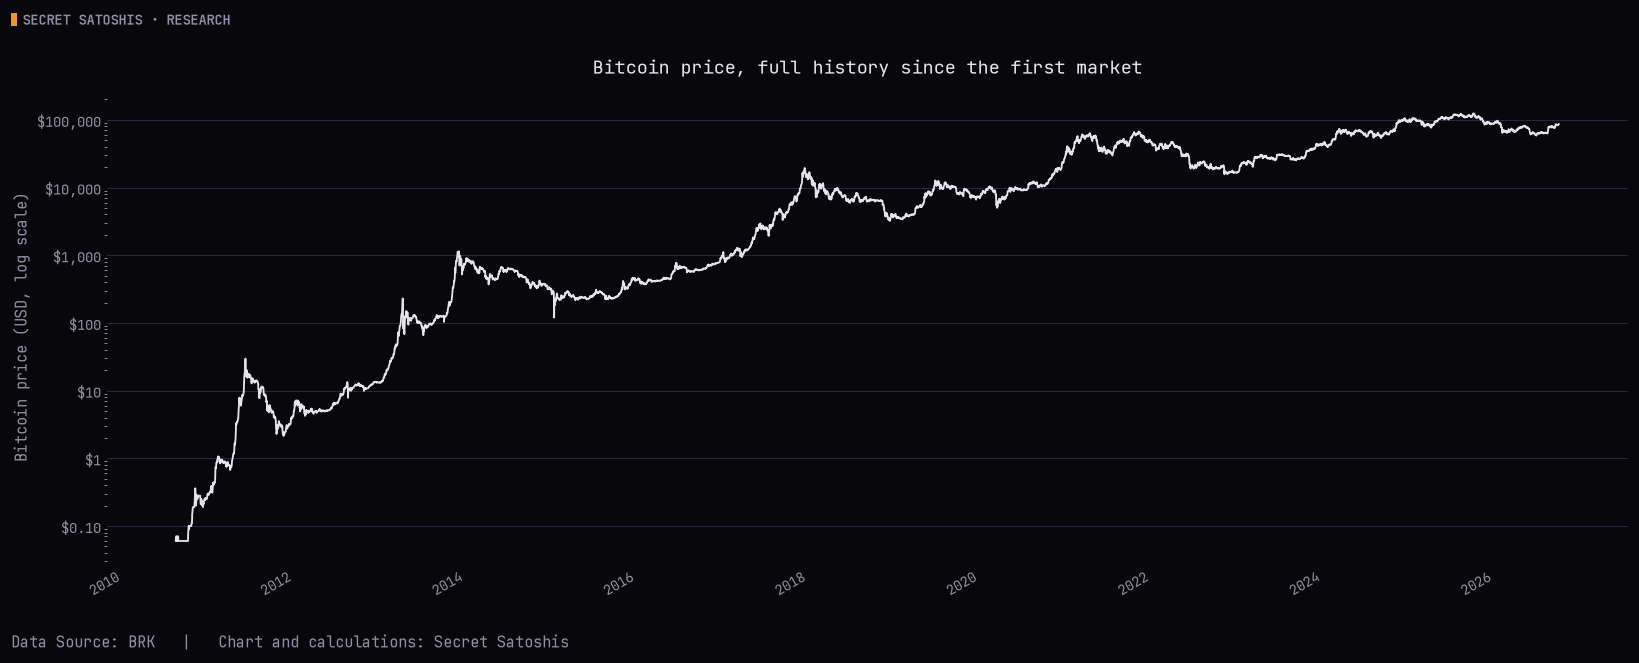

2010-08-16: $0.06
2026-10-04: $86,246.24


In [8]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(daily.index, daily["price_close"], color=PRIMARY, linewidth=1.2)
price_axis(ax)
finish(fig, "Bitcoin price, full history since the first market", ax, sources=[BRK])
print(f"{daily.index.min().date()}: ${daily['price_close'].iloc[0]:,.2f}")
print(f"{daily.index.max().date()}: ${daily['price_close'].iloc[-1]:,.2f}")

---

# 6. A UTXO cost-basis proxy: realized capitalization

Market cap values every coin at today's price. It answers "what is the whole stock worth right now" and nothing else.

**Realized cap** asks a different question. Value every UTXO at the market price when it was created, then add those values up. A coin last moved when price was \$8,000 counts as \$8,000 regardless of today's quote. The result is an output-level **cost-basis proxy**. A self-transfer or change output is repriced too, so it is not the aggregate amount investors actually paid.

Divide it by supply and you get **realized price**: the BTC-weighted average creation-price proxy for the current UTXO set. It is not a holder-weighted break-even price, because the chain does not identify holders.

Two things follow immediately.

**Realized price is far smoother than market price**, because it only updates when coins move. Most coins do not move on most days, so most of the cost basis is inherited from the past.

**Realized cap can fall without anyone withdrawing money.** This trips people up. If a coin last valued at \$60,000 moves when price is \$30,000, the stock's recorded proxy drops by \$30,000 — but nothing necessarily left the system; the output was simply re-priced downward. Realized cap is an output-level valuation proxy, not a measure of fund flows.

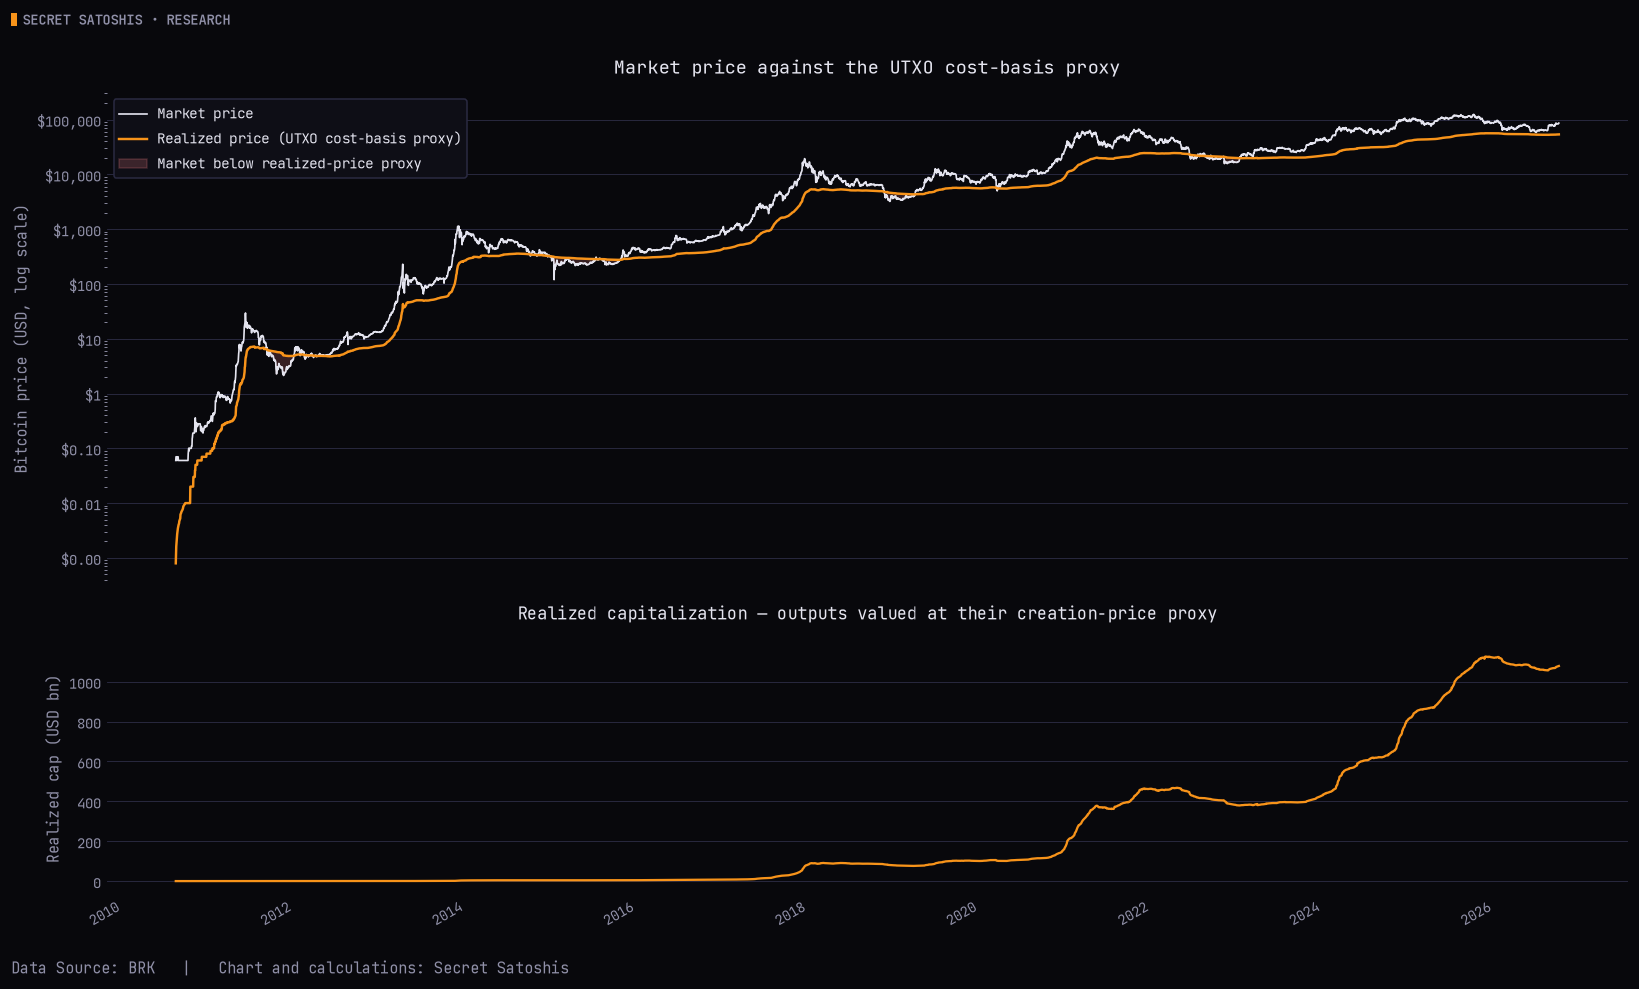

Days with market price below realized-price proxy: 765 of 5,894 (13.0%)
Today: price $86,246 vs realized-price proxy $53,686 (1.61x)


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(daily.index, daily["price_close"], color=PRIMARY, linewidth=1.1, label="Market price")
# Realized price is rounded to exactly 0.0 for the first 41 days while the
# underlying per-coin value is below the provider's reporting precision, so
# it is dropped rather than plotted or counted.
realized = daily["realized_price"].replace(0, np.nan)

ax1.plot(daily.index, realized, color=ORANGE, linewidth=1.6,
         label="Realized price (UTXO cost-basis proxy)")
ax1.fill_between(daily.index, daily["price_close"], realized,
                 where=daily["price_close"] < realized,
                 color=RED, alpha=.20, label="Market below realized-price proxy")
price_axis(ax1); ax1.legend(loc="upper left", fontsize=9)
ax1.set_title("Market price against the UTXO cost-basis proxy", fontsize=12, pad=12)

ax2.plot(daily.index, daily["realized_cap"] / 1e9, color=ORANGE, linewidth=1.5)
ax2.set_ylabel("Realized cap (USD bn)")
ax2.set_title("Realized capitalization — outputs valued at their creation-price proxy", fontsize=11)
finish(fig, sources=[BRK])

below = (daily["price_close"] < realized).where(realized.notna())
print(f"Days with market price below realized-price proxy: {int(below.sum()):,} "
      f"of {int(below.notna().sum()):,} ({below.mean()*100:.1f}%)")
print(f"Today: price ${daily['price_close'].iloc[-1]:,.0f} vs "
      f"realized-price proxy ${daily['realized_price'].iloc[-1]:,.0f} "
      f"({daily['price_close'].iloc[-1]/daily['realized_price'].iloc[-1]:.2f}x)")

### The same question, asked two more ways

That ratio at the end — price divided by realized price — has a name: **MVRV**. It compares the market value of the whole stock against its realized-cap proxy: above one, market value exceeds that proxy; below one, it does not. It compresses the relationship into a single line, and because both halves are dollars, the line means the same thing in 2013 as it does today.

**Supply in profit** applies the comparison one coin at a time. Compare today's price with each UTXO's creation-price proxy and count the coins above that proxy. The result is a share of the stock: 80% means four coins in five have a creation-price proxy below today's market price.

What gets counted is coins, not entities and not dollars. A hundred coins in one output count a hundred times.

Read it against the halfway line. Above 50%, most of the stock has a creation-price proxy below market price. Below it, most coins have a proxy above market price — a state the network has occupied during parts of major drawdowns. The measure does not identify owner-level gains or purchase costs.

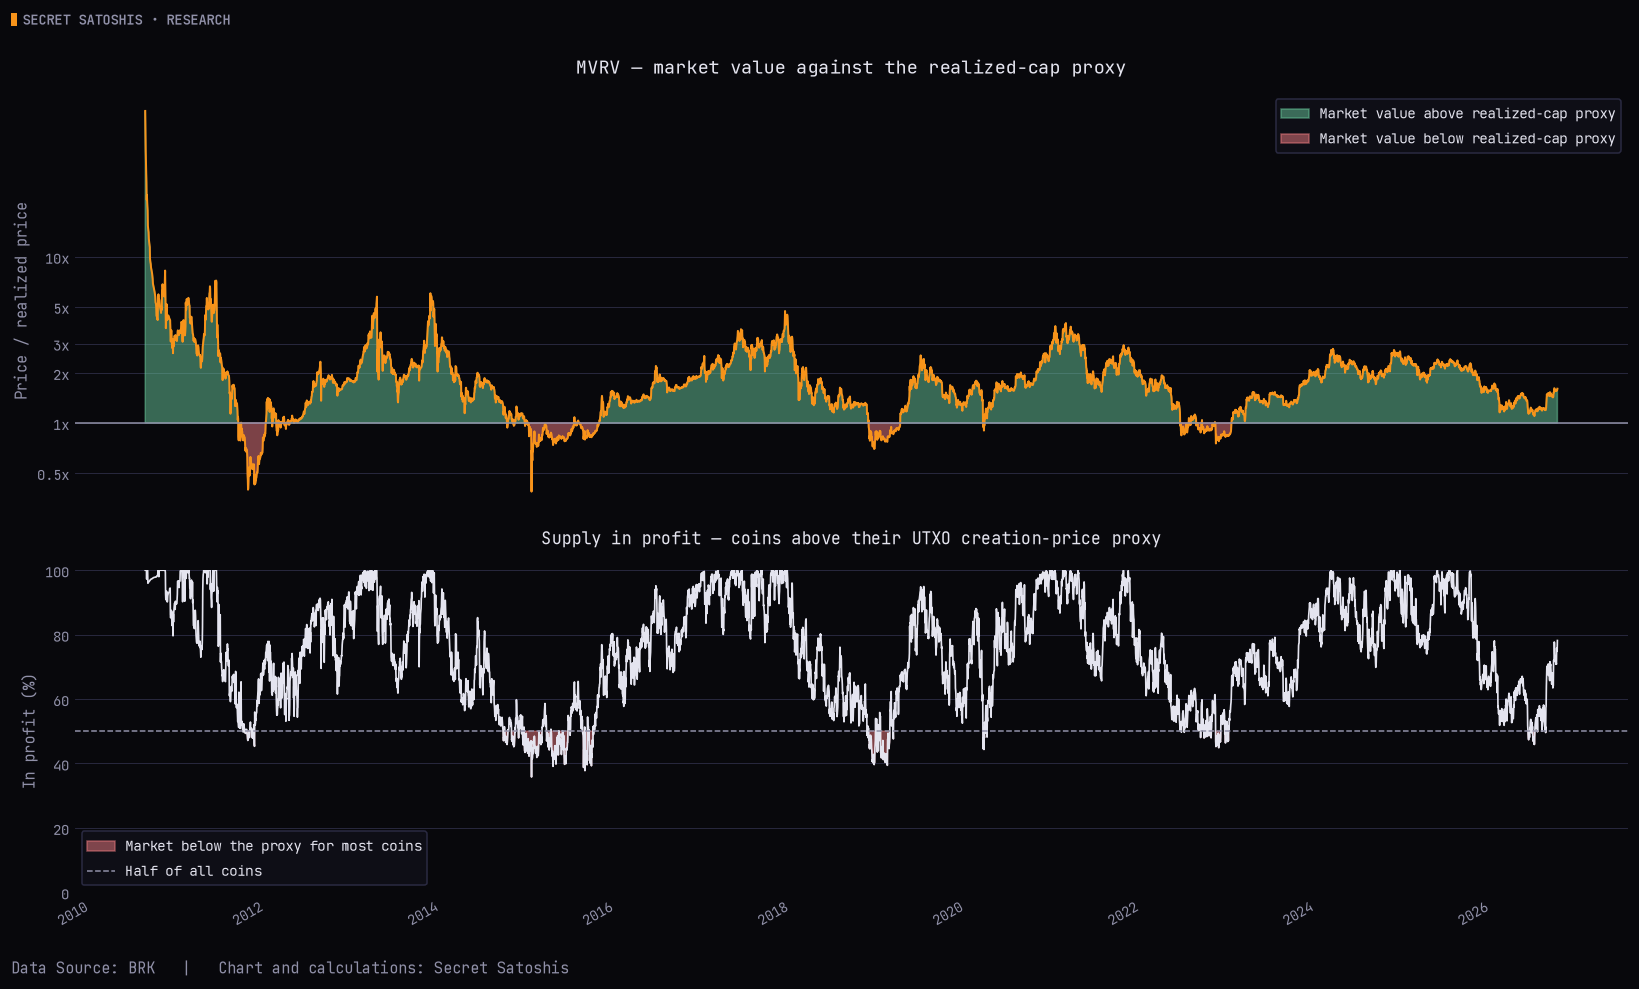

MVRV at cutoff               1.61x
Supply in profit at cutoff   78.2%
Median MVRV                  1.71x
Median supply in profit      75.9%
Days below the halfway line    7.3%


In [10]:
sip = daily["supply_in_profit"] / daily["supply"] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                               gridspec_kw={"height_ratios": [1.3, 1]})

ax1.plot(daily.index, daily["mvrv"], color=ORANGE, linewidth=1.3)
ax1.axhline(1, color=GREY, linewidth=1)
ax1.fill_between(daily.index, 1, daily["mvrv"], where=daily["mvrv"] >= 1,
                 color=GREEN, alpha=.5, label="Market value above realized-cap proxy")
ax1.fill_between(daily.index, 1, daily["mvrv"], where=daily["mvrv"] < 1,
                 color=RED, alpha=.5, label="Market value below realized-cap proxy")
ax1.set_yscale("log"); ax1.set_ylabel("Price / realized price")
ax1.set_yticks([0.5, 1, 2, 3, 5, 10]); ax1.minorticks_off()
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}x"))
ax1.legend(fontsize=9, loc="upper right")
ax1.set_title("MVRV — market value against the realized-cap proxy",
              fontsize=12, pad=12)

ax2.plot(sip.index, sip, color=PRIMARY, linewidth=1.1)
# Filled from the halfway line rather than from zero, so the shading reads as
# distance below the line — the same way the panel above reads against 1x.
ax2.fill_between(sip.index, 50, sip, where=sip < 50, color=RED, alpha=.5,
                 label="Market below the proxy for most coins")
ax2.axhline(50, color=GREY, linestyle="--", linewidth=1, label="Half of all coins")
ax2.set_ylabel("In profit (%)"); ax2.set_ylim(0, 100)
ax2.legend(fontsize=9, loc="lower left")
ax2.set_title("Supply in profit — coins above their UTXO creation-price proxy",
              fontsize=11)
finish(fig, sources=[BRK])

print(f"{'MVRV at cutoff':<26}{daily['mvrv'].iloc[-1]:>7.2f}x")
print(f"{'Supply in profit at cutoff':<26}{sip.iloc[-1]:>7.1f}%")
print(f"{'Median MVRV':<26}{daily['mvrv'].median():>7.2f}x")
print(f"{'Median supply in profit':<26}{sip.median():>7.1f}%")
print(f"{'Days below the halfway line':<26}{(sip < 50).mean() * 100:>7.1f}%")

Five metrics carry the rest of this notebook. **Age** says how long supply has sat still, **coin-days destroyed** says how much dormancy ended when it moved, **realized price** supplies a UTXO cost-basis proxy, **supply in profit** says how much supply is above that proxy, and **realized profit and loss** measures output-level repricing when UTXOs move. Everything after this section is a finer cut of those five.

---

# 7. Two groups: recently moved and long-term UTXOs

BRK's standard cut is at **150 days** — five fixed 30-day months. Coins untouched at least that long belong to the long-term UTXO cohort; anything more recent belongs to the short-term cohort.

The 150-day threshold is BRK's cohort convention. It is a heuristic classification rather than a protocol boundary: outputs do not change economic identity on day 150, and conclusions should not depend on treating the cut-off as exact.

It is the same idea as the age cohorts in section 3, one rung lower. The long-term cohort sits just below the one-year threshold — the shortest rung of that ladder, and a much wider one. The output below compares the share of supply still for 150 days with the share still for a year; the gap between them is the coins between five months and a year old.

The split is exhaustive: every coin is in exactly one group, and the two sum to total supply. Worth confirming rather than assuming — it is the property that makes this a decomposition rather than two overlapping estimates.

What the split adds is an output-level realized-price proxy for each group. Long-term UTXOs were created earlier, while short-term UTXOs were created more recently. When market price sits between the two proxies, the groups occupy different unrealized-P/L states; the chain does not reveal whether ownership changed or what decision produced the move.

The first chart is the split itself. The second shows each group's realized-price proxy. The short-term line shadows market price because those outputs were created recently, whether by a trade, a self-transfer or change.

LTH + STH reconciles to total supply within 0.01 coins (0.000000% of supply)
Every coin is in exactly one group, so this is a true decomposition.



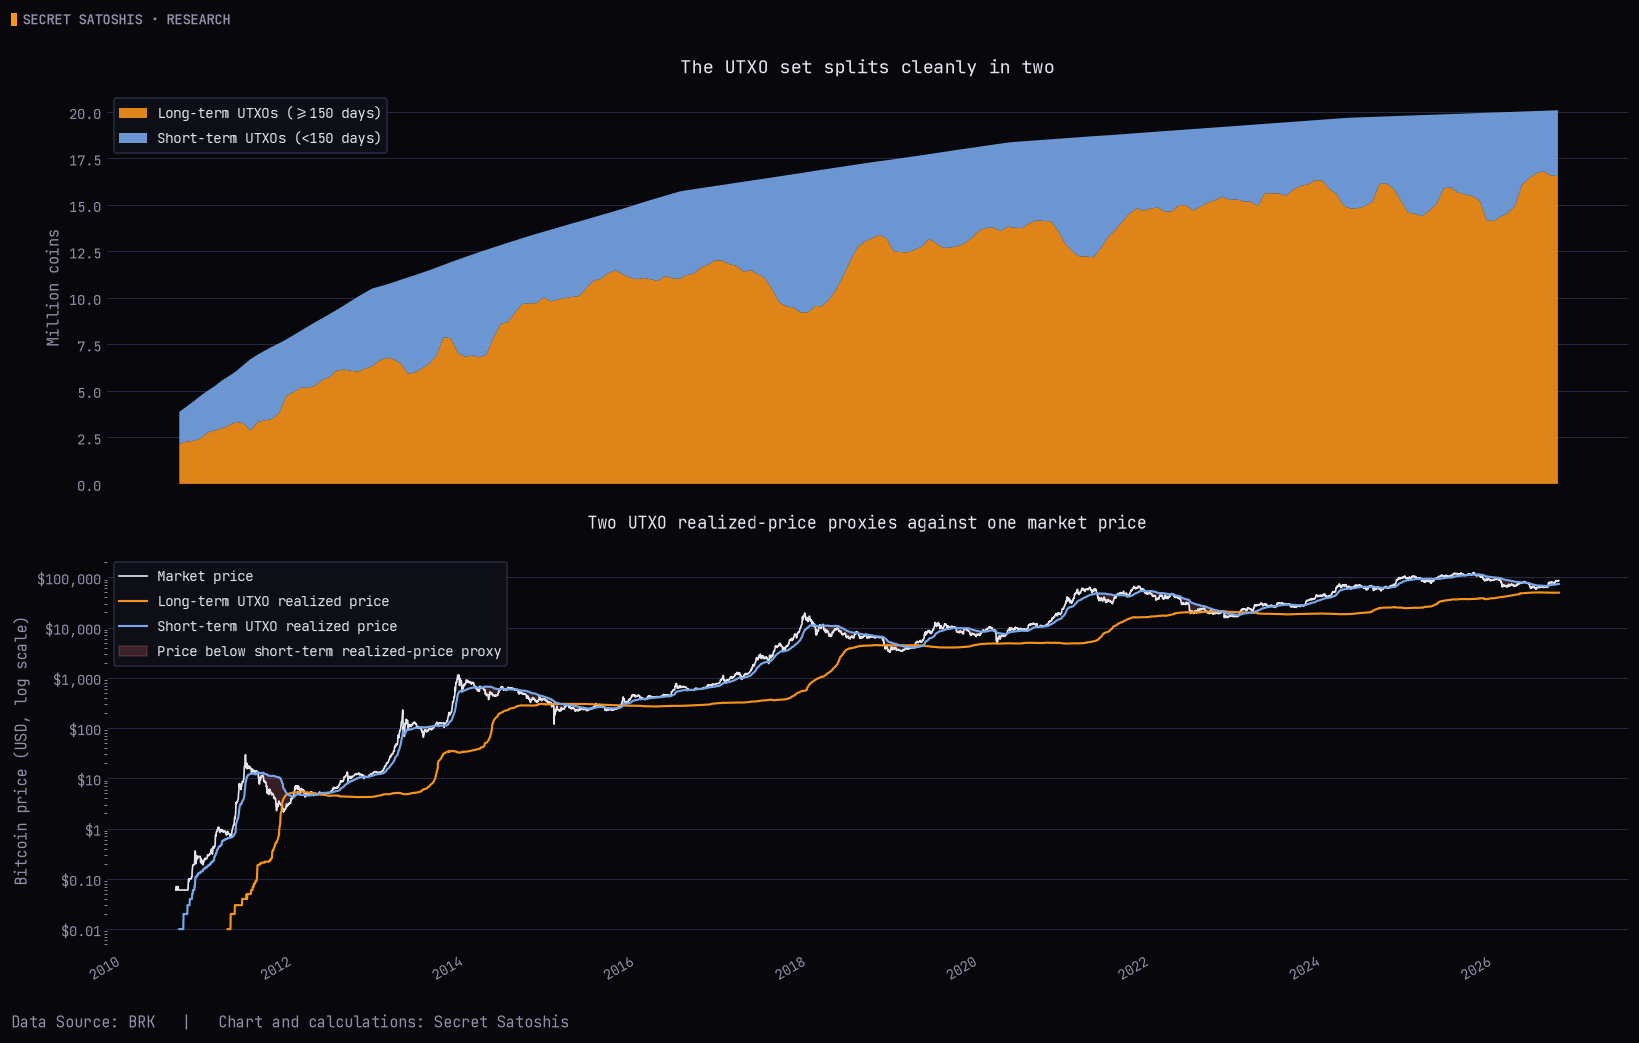

Long-term UTXOs contain 82.5% of supply at a realized price of $49,444
Short-term UTXOs contain 17.5% at a realized price of $73,733

Still for 150+ days: 82.5% of supply; still for 1+ year: 63.3%.
The gap — coins between five months and a year old — is 3.9 million coins.


In [11]:
lth, sth = daily["lth_supply"], daily["sth_supply"]

err = validate_cohorts(daily)
print(f"LTH + STH reconciles to total supply within {err:.2f} coins "
      f"({err/daily['supply'].iloc[-1]*100:.6f}% of supply)")
print("Every coin is in exactly one group, so this is a true decomposition.\n")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9.5), sharex=True)

m_lth = lth.resample("ME").last(); m_sth = sth.resample("ME").last()
keep = m_lth.index <= LAST_DAY
ax1.stackplot(m_lth.index[keep], m_lth[keep] / 1e6, m_sth[keep] / 1e6,
              labels=["Long-term UTXOs (>=150 days)", "Short-term UTXOs (<150 days)"],
              colors=[ORANGE, BLUE], alpha=.9)
ax1.set_ylabel("Million coins"); ax1.legend(loc="upper left", fontsize=9)
ax1.set_title("The UTXO set splits cleanly in two", fontsize=12, pad=12)

ax2.plot(daily.index, daily["price_close"], color=PRIMARY, linewidth=1.1, label="Market price")
ax2.plot(daily.index, daily["lth_realized_price"].replace(0, np.nan), color=ORANGE,
         linewidth=1.4, label="Long-term UTXO realized price")
ax2.plot(daily.index, daily["sth_realized_price"].replace(0, np.nan), color=BLUE,
         linewidth=1.4, label="Short-term UTXO realized price")
ax2.fill_between(daily.index, daily["price_close"],
                 daily["sth_realized_price"].replace(0, np.nan),
                 where=daily["price_close"] < daily["sth_realized_price"],
                 color=RED, alpha=.20, label="Price below short-term realized-price proxy")
price_axis(ax2); ax2.legend(loc="upper left", fontsize=9)
ax2.set_title("Two UTXO realized-price proxies against one market price",
              fontsize=11)
finish(fig, sources=[BRK])

print(f"Long-term UTXOs contain {lth.iloc[-1]/daily['supply'].iloc[-1]*100:.1f}% of supply "
      f"at a realized price of ${daily['lth_realized_price'].iloc[-1]:,.0f}")
print(f"Short-term UTXOs contain {sth.iloc[-1]/daily['supply'].iloc[-1]*100:.1f}% "
      f"at a realized price of ${daily['sth_realized_price'].iloc[-1]:,.0f}")
one_year = daily["utxos_over_1y_old_supply"].iloc[-1]
print(f"\nStill for 150+ days: {lth.iloc[-1]/daily['supply'].iloc[-1]*100:.1f}% of supply; "
      f"still for 1+ year: {one_year/daily['supply'].iloc[-1]*100:.1f}%.")
print(f"The gap — coins between five months and a year old — is {(lth.iloc[-1]-one_year)/1e6:.1f} million coins.")

---

# 8. Why a cohort changes size

Ask what can change the number of coins in the "one year or older" bucket. There are exactly two possibilities, and no others:

- A coin that has been still for 364 days quietly turns 365 and **ages in**.
- A coin already in the bucket gets **spent out**, and its clock resets to zero.

That is the complete list. Coins cannot appear in an old bucket from nowhere — age cannot be manufactured — and they cannot leave without being moved. Which gives an identity:

```
   change in supply(X+)  =  aged in(X+)  −  spent out(X+)
```

Only one of those two terms is published. Spending is reported directly; aging-in is not reported by anyone. But we *observe* the change in the bucket and we *observe* the spending, so the missing term falls out:

```
   aged in  =  change in supply  +  spent out
```

Without it, "supply is aging" is an observation about a line going up. With it, the line can be decomposed: a bucket growing because a wave of UTXOs is crossing the age threshold is a different event from a bucket growing because few aged outputs leave it, and now they can be told apart.

One thing the identity counts generously. A coin that comes back as change starts its clock again, so the same coin can mature into the same bucket more than once. Aged-in is coins crossing a birthday, not distinct coins reaching an age for the first time.

**The identity is also a test.** Aging-in is a count of coins crossing a birthday, so it can never be negative. If our arithmetic ever produced a negative, either the data or our alignment of it would be wrong. So we check it on every day of history.

In [12]:
spent = pd.DataFrame({f"{a}+": daily[f"utxos_over_{a}_old_transfer_volume_daily"]
                      for a in COHORTS})

# Published values are rounded, so exact zero is the wrong bar to hold the
# arithmetic to. One coin a day is below anything the notebook reads.
TOL = 1.0

# Section 3 built the cohort stocks off the full record, from the release's
# start in 2010. The flow series only exist over the validated frame, so the identity —
# and everything downstream of it — is evaluated on the days both cover.
cohort_stock = stocks.reindex(spent.index)
cohort_bands = exclusive_bands(cohort_stock)

stock_change = cohort_stock.diff()
aged_in = stock_change + spent          # the identity, rearranged

print("Testing the identity on every day of history.")
print("Aged-in counts coins crossing a birthday, so it cannot be negative:\n")
ok = True
for c in cohort_stock.columns:
    v = aged_in[c].dropna()
    neg = int((v < -TOL).sum())
    ok &= neg == 0
    # A cohort reads 0 = 0 + 0 before any coins are old enough to be in it.
    # Those days are not a test of anything, so the minimum is reported over
    # the period where the cohort actually exists.
    live = v[cohort_stock[c].reindex(v.index) > 0]
    print(f"  {c:>5}   below -{TOL:.0f} on {neg:>4} of {len(v):,} days   "
          f"min once populated {live.min():>10,.0f}   "
          f"median {live.median():>9,.0f} coins/day")
if not ok:
    raise ValueError("the identity failed — check the flow/stock alignment")

print("\nIt holds everywhere — the aged-in series never goes negative.")

Testing the identity on every day of history.
Aged-in counts coins crossing a birthday, so it cannot be negative:

    1y+   below -1 on    0 of 5,893 days   min once populated        250   median     5,216 coins/day
    2y+   below -1 on    0 of 5,893 days   min once populated          0   median     2,879 coins/day
    3y+   below -1 on    0 of 5,893 days   min once populated         -0   median     1,985 coins/day
    4y+   below -1 on    0 of 5,893 days   min once populated          0   median     1,485 coins/day
    5y+   below -1 on    0 of 5,893 days   min once populated          0   median     1,133 coins/day
   10y+   below -1 on    0 of 5,893 days   min once populated          0   median       667 coins/day

It holds everywhere — the aged-in series never goes negative.


### Seeing both sides

With the identity in hand, a bucket's change stops being one line and becomes two opposing flows. The chart below shows them for the one-year threshold: coins maturing past their first birthday above the axis, coins being spent out below it, and the net change as the white line.

The two are usually large and nearly cancelling. The *net* number, which is what a single supply line shows you, is a small difference between two big flows. Periods where the net barely moves can hide enormous churn, and periods of dramatic net change sometimes come from one side going quiet rather than the other surging.

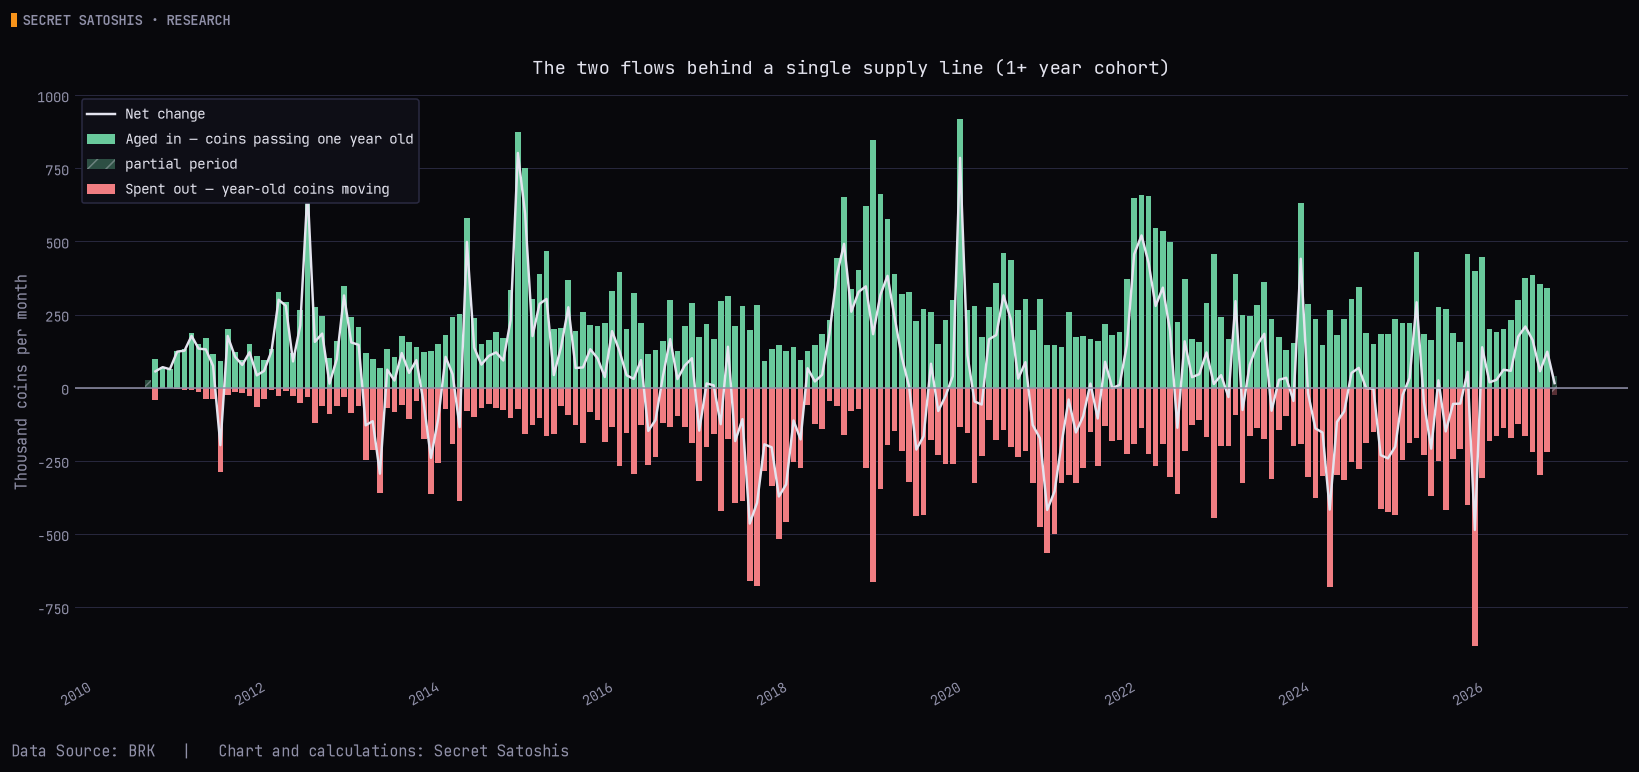

Last six complete months (coins):

             aged in  spent out       net
date                                     
2026-04-30  230517.0   172563.0   57954.0
2026-05-31  299818.0   125534.0  174284.0
2026-06-30  375701.0   166345.0  209355.0
2026-07-31  384134.0   221177.0  162957.0
2026-08-31  355494.0   299046.0   56448.0
2026-09-30  341270.0   218018.0  123252.0

Across complete months the flows average 266,037 in and 205,715 out,
for a net of 60,322. Most of the activity cancels.


In [13]:
m_aged, centers, full = aggregated(aged_in["1y+"], "ME", "M")
m_spent, _, _ = aggregated(spent["1y+"], "ME", "M")
m_net = cohort_stock["1y+"].resample("ME").last().diff()

fig, ax = plt.subplots(figsize=(15, 7))
ax.bar(centers[full], m_aged[full] / 1000, width=24, color=GREEN,
       label="Aged in — coins passing one year old")
ax.bar(centers[~full], m_aged[~full] / 1000, width=24, color=GREEN, alpha=.35,
       hatch="//", label="partial period")
ax.bar(centers[full], -m_spent[full] / 1000, width=24, color=RED,
       label="Spent out — year-old coins moving")
ax.bar(centers[~full], -m_spent[~full] / 1000, width=24, color=RED, alpha=.35, hatch="//")
ax.plot(centers, m_net / 1000, color=PRIMARY, linewidth=1.6, label="Net change")
ax.axhline(0, color=GREY, linewidth=1)
ax.set_ylabel("Thousand coins per month")
ax.legend(fontsize=9, loc="upper left")
finish(fig, "The two flows behind a single supply line (1+ year cohort)", ax, sources=[BRK])

recent = pd.DataFrame({"aged in": m_aged[full], "spent out": m_spent[full],
                       "net": m_net[full]}).tail(6)
print("Last six complete months (coins):\n")
print(recent.round(0).to_string())
print(f"\nAcross complete months the flows average {m_aged[full].mean():,.0f} in "
      f"and {m_spent[full].mean():,.0f} out,")
print(f"for a net of {m_net[full].mean():,.0f}. Most of the activity cancels.")

---

# 9. Net aging: is old supply growing or draining?

The net of those two flows, measured over a window, is what we will call **net aging**. Positive means a cohort is growing — more coins maturing in than being spent out. Negative means the reverse: aged outputs are leaving the cohort faster than it is being replenished.

The window matters. Over a single day the number is noise. Widen it and the reading steadies, at the cost of arriving later — the same trade section 4 made with dormancy. So the charts show three: a month, a quarter and a year, each against the same price line.

Read them as the cohort filling or draining. Stretches above zero are periods when more supply matured into the cohort than left it; stretches below zero are periods when previously dormant coins were leaving faster than new ones arrived. The month catches every wobble, the year keeps only what lasted.

One thing the sign does not tell you is motive or ownership. The inflow leg is fixed by outputs created a year earlier that remain unspent, so a positive reading combines past UTXO creation with current non-movement.

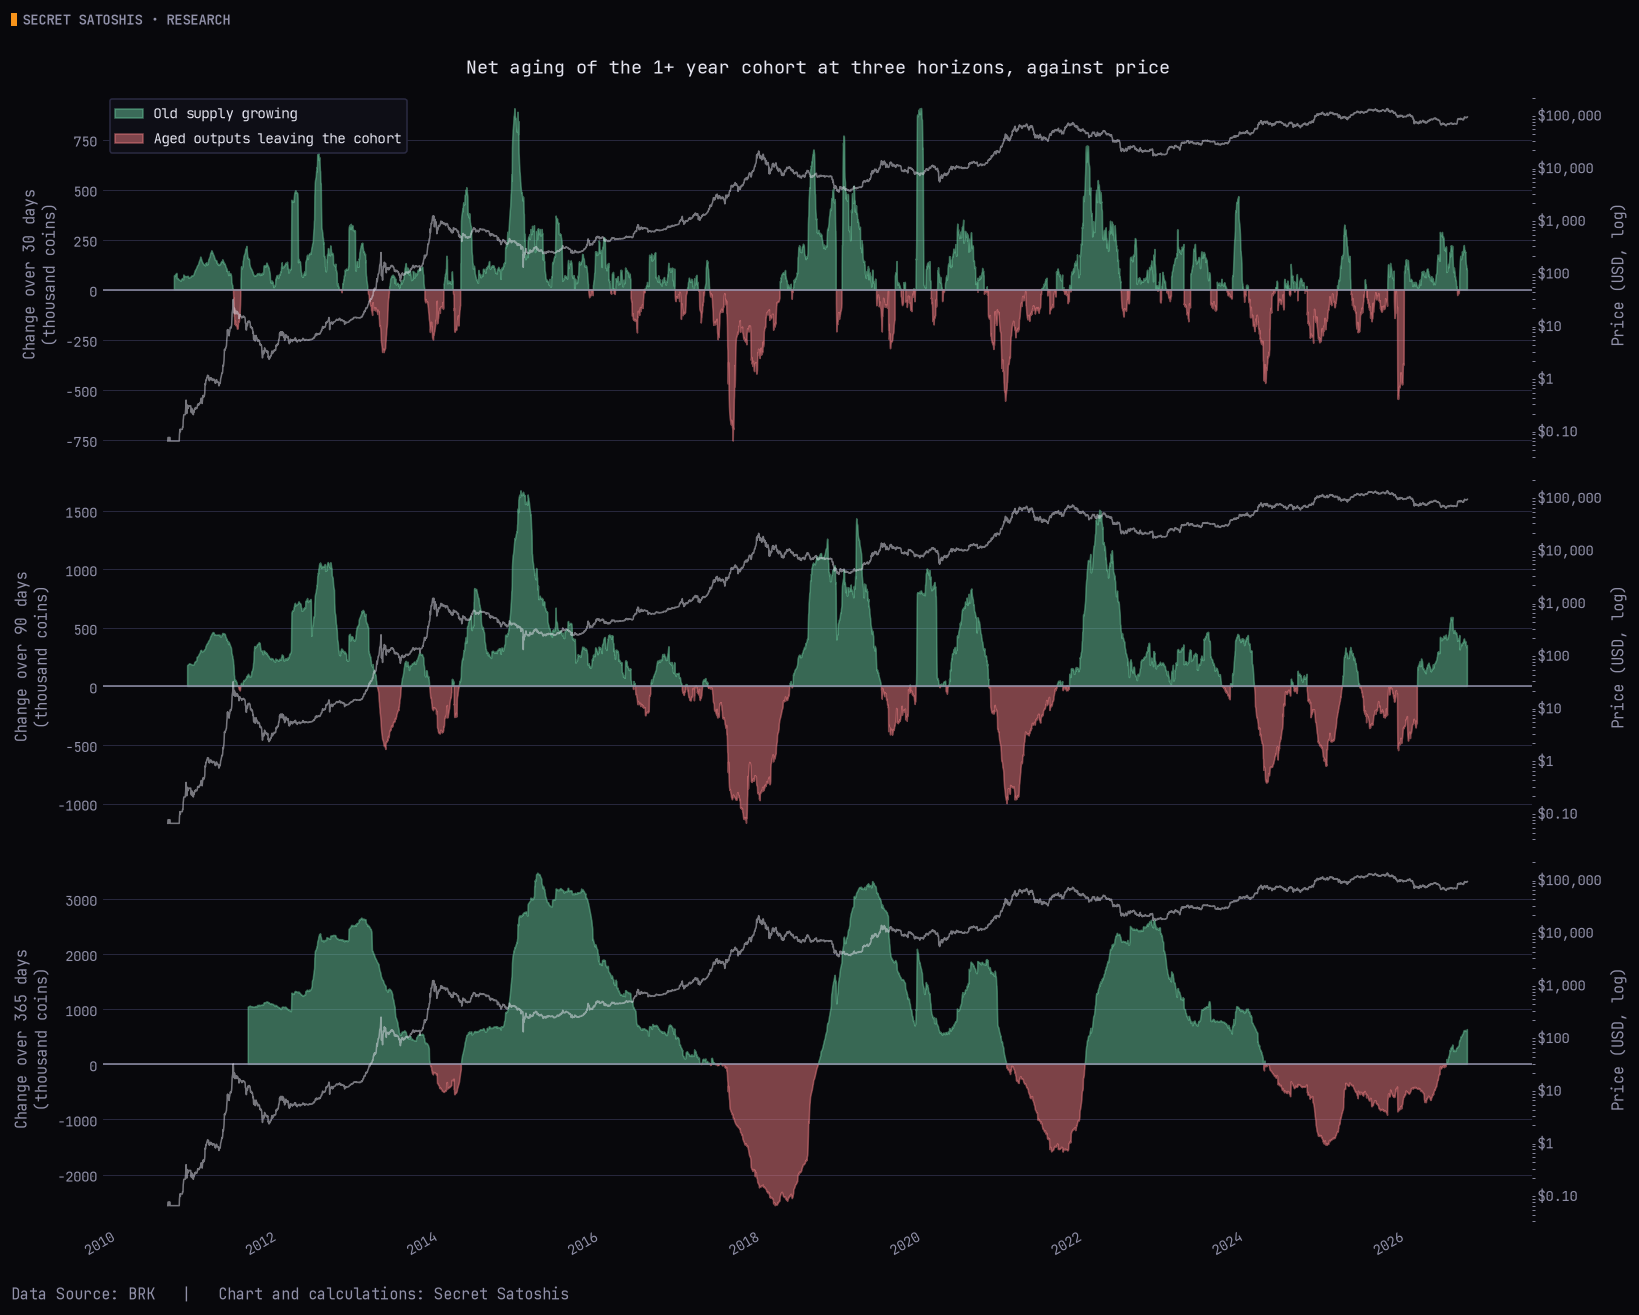

window        growing  draining        latest
30 days           66%       34%       +96,763
90 days           67%       33%      +349,311
365 days          68%       32%      +629,959


In [14]:
NET_WINDOWS = [(30, "Change over 30 days"), (90, "Change over 90 days"),
               (365, "Change over 365 days")]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for ax, (window, title) in zip(axes, NET_WINDOWS):
    net = cohort_stock["1y+"].diff(window)
    ax.fill_between(net.index, 0, net / 1000, where=net >= 0,
                    color=GREEN, alpha=.5, label="Old supply growing")
    ax.fill_between(net.index, 0, net / 1000, where=net < 0,
                    color=RED, alpha=.5, label="Aged outputs leaving the cohort")
    ax.axhline(0, color=GREY, linewidth=1)
    # The window labels the y-axis rather than the panel title, so the figure
    # carries one headline instead of a headline plus two bare fragments.
    ax.set_ylabel(f"{title}\n(thousand coins)")

    # Price on its own axis in every panel, so each one can be read alone.
    price = ax.twinx()
    price.plot(daily.index, daily["price_close"], color=PRIMARY, linewidth=1, alpha=.5)
    price_axis(price, "Price (USD, log)"); price.grid(False)
    price.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: ""))

axes[0].legend(loc="upper left", fontsize=9)
axes[0].set_title("Net aging of the 1+ year cohort at three horizons, against price",
                  fontsize=12, pad=12)
finish(fig, sources=[BRK])

print(f"{'window':<12}{'growing':>9}{'draining':>10}{'latest':>14}")
for window, title in NET_WINDOWS:
    net = cohort_stock["1y+"].diff(window).dropna()
    print(f"{title.replace('Change over ', ''):<12}{(net > 0).mean() * 100:>8.0f}%"
          f"{(net <= 0).mean() * 100:>9.0f}%{net.iloc[-1]:>+14,.0f}")

### The same question at every depth

One cohort can move for its own reasons. A wave of UTXO creation from exactly one year ago can push the one-year threshold around without describing the UTXO set broadly.

Asking every band at once helps. If only one band is moving, it may be the echo of a single past event. It is not a complete guard, though: one large wave propagates up the ladder year after year, so several bands moving together can still be one UTXO cohort aging in step rather than a broad-based change.

The chart below takes the middle window — 90 days — and applies it to each exclusive band. One thing not to misread: a band cannot show anything before coins of that age exist, so the 10-year band is genuinely blank until 2019. That is the chain being young, not a measurement of current behavior.

Read the two charts together and you have both halves of the question — how quickly age cohorts are filling or draining, and whether the pattern is broad or concentrated in one band.

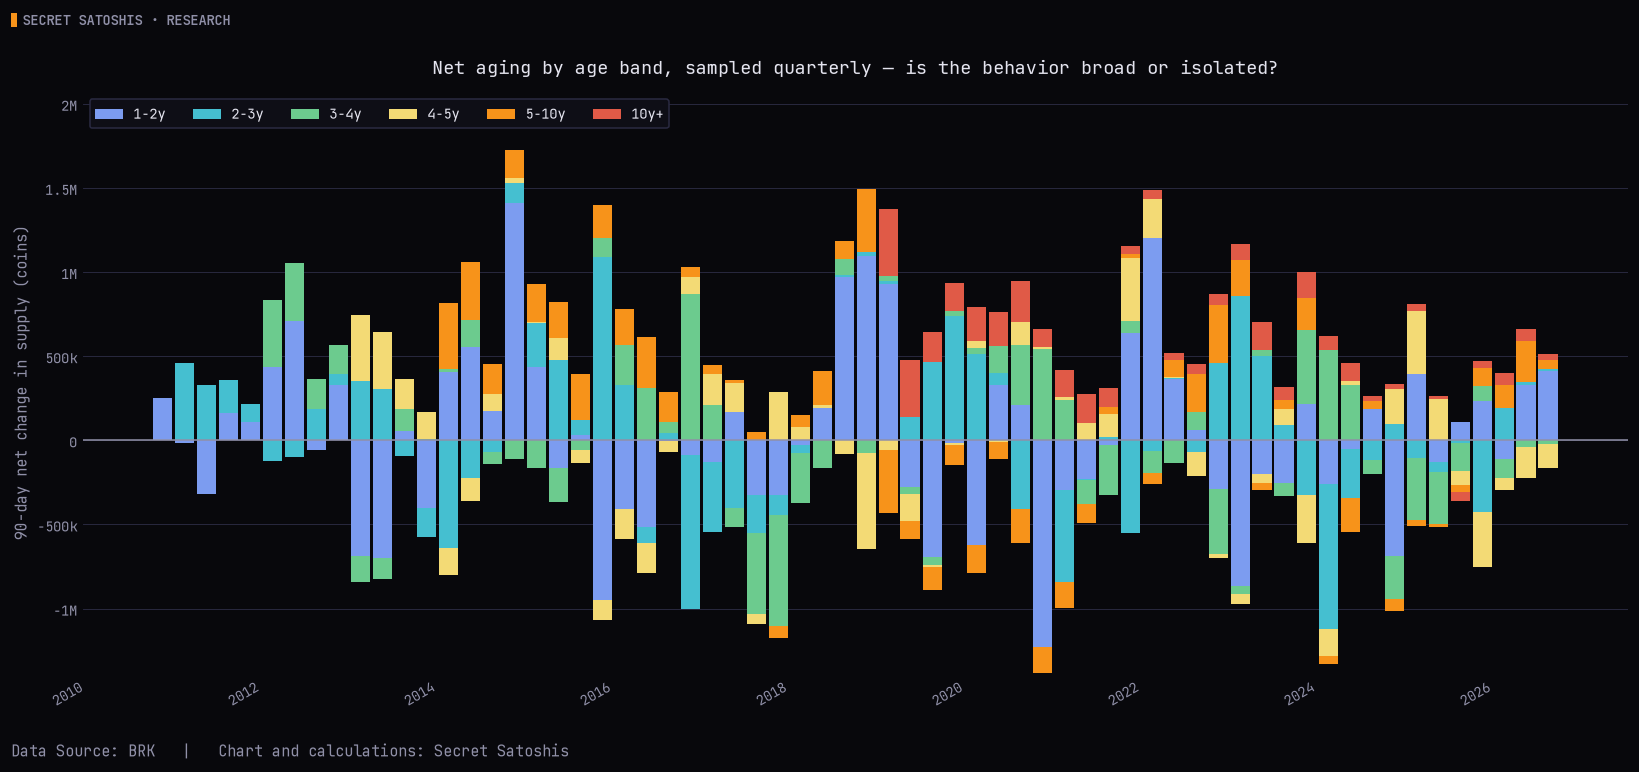

Latest 90-day net change by band, to 2026-10-04 (coins):

    1-2y      +452,121   growing
    2-3y       -20,879   draining
    3-4y       -16,330   draining
    4-5y      -158,135   draining
   5-10y       +54,069   growing
    10y+       +38,464   growing


In [15]:
band_net = cohort_bands.diff(90)

# Sampled quarterly rather than monthly. The measure is a 90-day change, so
# monthly bars would share sixty days of coverage with their neighbours while
# looking like separate buckets — the double-counting the notebook warns about.
q_band_net = band_net.resample("QE").last()
# A resample labels an unfinished quarter at its future quarter-end date. Keep
# only quarters for which that endpoint is actually covered by the data.
q_band_net = q_band_net[complete_periods(q_band_net.index, "Q").values]
centers = period_centers(q_band_net.index, "Q")

fig, ax = plt.subplots(figsize=(15, 7))
bottom_pos = np.zeros(len(q_band_net)); bottom_neg = np.zeros(len(q_band_net))
for c in q_band_net.columns:
    v = (q_band_net[c]).fillna(0).values
    p, n = np.clip(v, 0, None), np.clip(v, None, 0)
    ax.bar(centers, p, bottom=bottom_pos, width=80, color=BAND_COLORS[c], label=c)
    ax.bar(centers, n, bottom=bottom_neg, width=80, color=BAND_COLORS[c])
    bottom_pos += p; bottom_neg += n
ax.axhline(0, color=GREY, linewidth=1)
ax.set_ylabel("90-day net change in supply (coins)")
ax.yaxis.set_major_formatter(FuncFormatter(compact))
ax.set_ylim(top=ax.get_ylim()[1] * 1.2)  # room for the legend above the tallest bar
ax.legend(ncol=6, fontsize=9, loc="upper left")
finish(fig, "Net aging by age band, sampled quarterly — is the behavior broad or isolated?", ax, sources=[BRK])

latest = band_net.iloc[-1]
print(f"Latest 90-day net change by band, to {band_net.index[-1].date()} (coins):\n")
for c in cohort_bands.columns:
    v = latest[c]
    print(f"  {c:>6}  {v:>+12,.0f}   {'growing' if v > 0 else 'draining'}")

---

# 10. Aging, seen through profit and loss

Every output that moves receives an output-level repricing measurement. An indexer compares the market price when the output is spent with the price when it was created, and uses BRK's 150-day line to split the groups. The resulting realized profit or loss is a UTXO metric, not proof of a sale or cash booked by an owner.

Supply in profit counted UTXO value above or below its creation-price proxy. Here, positive months mean the outputs spent were repriced upward in aggregate; negative months mean they were repriced downward.

One thing to hold in mind. The calculation runs over every coin in every output consumed, change included, and the chain has no way to say which of those coins found a new holder. These are figures about outputs spent and the prices attached to them, not a ledger of what anyone banked.

Split by group, the mechanics are not symmetric. Long-term UTXOs can record large positive repricing when price is far above an older creation-price proxy. Short-term UTXOs are more responsive to recent drawdowns because their proxy is more recent.

Both groups are stacked on one chart, positive repricing upward and negative repricing downward, with price behind them. A month where the groups have opposite signs shows both rather than netting them into something small and misleading.

That makes this the last angle on the same behavior. Age says where supply sits, net aging says which way it is moving, and realized profit and loss says how spent outputs were repriced. It does not report ownership change or motive.

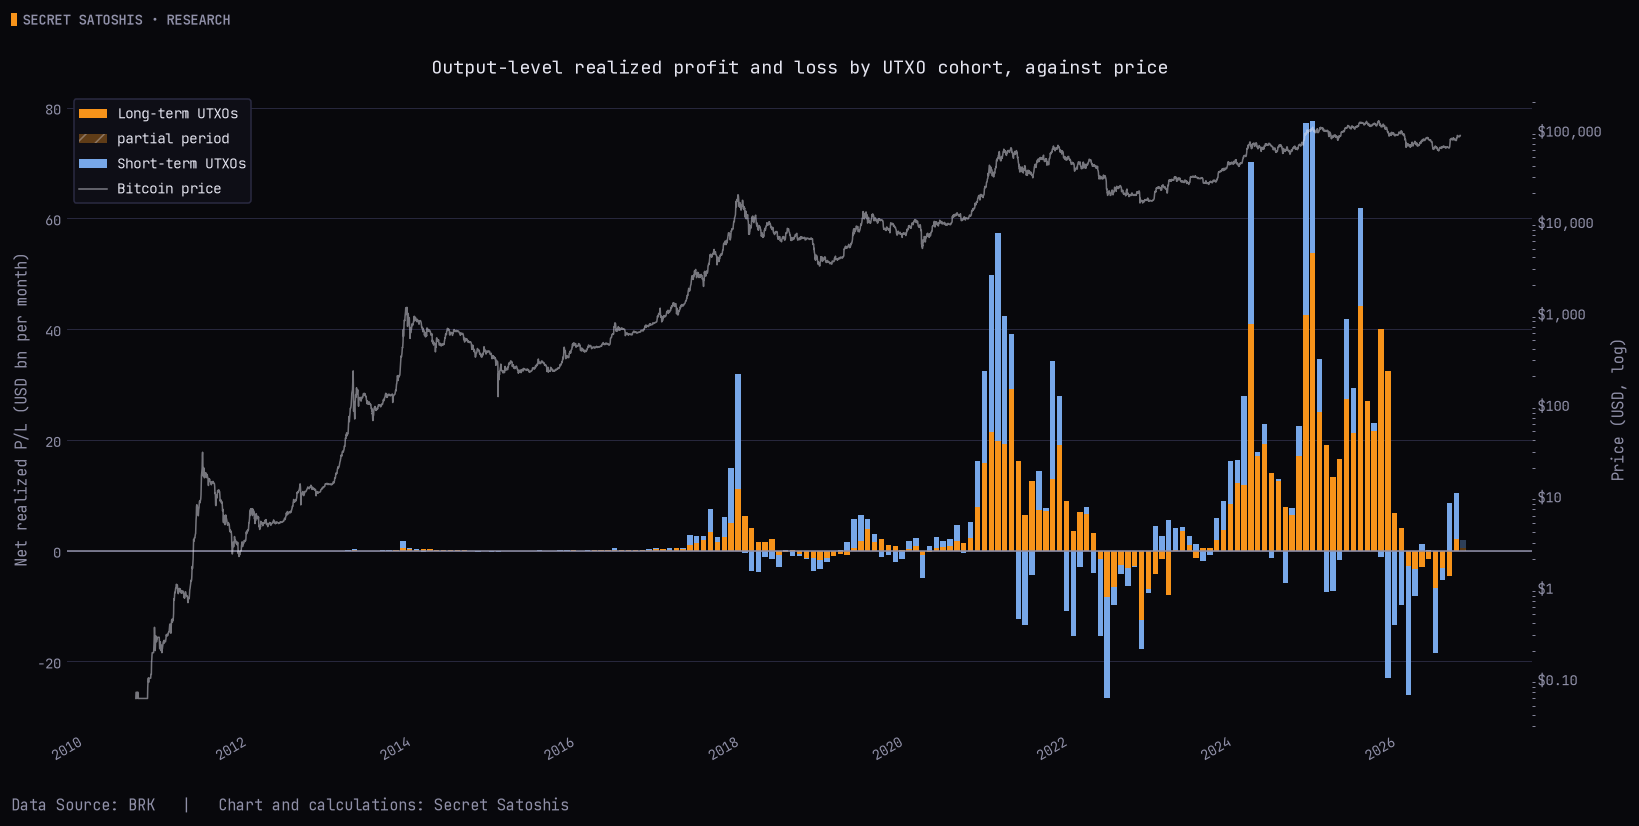

                      gain months            best month           worst month
Long-term UTXOs               72%     +53.8bn 2024-12      -12.6bn 2022-11
Short-term UTXOs              59%     +37.5bn 2021-02      -23.3bn 2026-02

Last three complete months (USD bn):
            long-term  short-term
date                             
2026-07-31      -3.19       -2.14
2026-08-31      -4.49        8.63
2026-09-30       2.06        8.42


In [16]:
# Net realized profit and loss for each group, in USD billions per month.
lth_daily = (daily["lth_realized_profit_daily"] - daily["lth_realized_loss_daily"]) / 1e9
sth_daily = (daily["sth_realized_profit_daily"] - daily["sth_realized_loss_daily"]) / 1e9
lth_net_pnl, centers, full = aggregated(lth_daily, "ME", "M")
sth_net_pnl, _, _ = aggregated(sth_daily, "ME", "M")

fig, ax = plt.subplots(figsize=(15, 7.5))

# Stacked on both sides of zero: gains pile upward, losses downward, so a month
# where one group is repriced upward while the other is repriced downward shows both
# instead of netting them into a single misleading bar.
up_to = np.zeros(len(lth_net_pnl)); down_to = np.zeros(len(lth_net_pnl))
for series, color, name in ((lth_net_pnl, ORANGE, "Long-term UTXOs"),
                            (sth_net_pnl, BLUE, "Short-term UTXOs")):
    v = series.fillna(0).values
    gain, loss = np.clip(v, 0, None), np.clip(v, None, 0)
    ax.bar(centers[full], gain[full], bottom=up_to[full], width=24, color=color, label=name)
    ax.bar(centers[full], loss[full], bottom=down_to[full], width=24, color=color)
    ax.bar(centers[~full], gain[~full], bottom=up_to[~full], width=24, color=color,
           alpha=.35, hatch="//", label="partial period" if color == ORANGE else None)
    ax.bar(centers[~full], loss[~full], bottom=down_to[~full], width=24, color=color,
           alpha=.35, hatch="//")
    up_to += gain; down_to += loss

ax.axhline(0, color=GREY, linewidth=1)
ax.set_ylabel("Net realized P/L (USD bn per month)")

price = ax.twinx()
price.plot(daily.index, daily["price_close"], color=PRIMARY, linewidth=1, alpha=.5,
           label="Bitcoin price")
price_axis(price, "Price (USD, log)"); price.grid(False)
price.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: ""))

# The price line lives on the twin axis, so its handle has to be carried across
# by hand or it never appears in the legend.
bars, bar_names = ax.get_legend_handles_labels()
line, line_name = price.get_legend_handles_labels()
ax.legend(bars + line, bar_names + line_name, fontsize=9, loc="upper left")
finish(fig, "Output-level realized profit and loss by UTXO cohort, against price", ax, sources=[BRK])

print(f"{'':<20}{'gain months':>13}{'best month':>22}{'worst month':>22}")
for name, series in (("Long-term UTXOs", lth_net_pnl[full]),
                     ("Short-term UTXOs", sth_net_pnl[full])):
    print(f"{name:<20}{(series > 0).mean() * 100:>12.0f}%"
          f"{series.max():>+10,.1f}bn {series.idxmax():%Y-%m}"
          f"{series.min():>+11,.1f}bn {series.idxmin():%Y-%m}")

print("\nLast three complete months (USD bn):")
print(pd.DataFrame({"long-term": lth_net_pnl[full],
                    "short-term": sth_net_pnl[full]}).tail(3).round(2).to_string())

---

# 11. Back to the beginning

We opened by separating the protocol's issuance schedule from the age structure of the existing UTXO set. The final comparison puts those two measurements beside each other without treating them as economically equivalent market supply.

On one side are coins created by the protocol — a known, published, decreasing stock increment. On the other is gross movement of outputs that had been dormant for a year or more — turnover that resets their age. Both are measured in BTC per year, but only the first changes the outstanding stock and neither measures coins offered for sale.

The ratio is therefore a scale comparison between issuance and dormancy ending, not a supply-pressure ratio. It can show that re-aging of existing outputs is large relative to new issuance, but it cannot identify ownership change, market availability or sell-side liquidity.

The chart carries a third bar, which is not part of that ratio. While old coins are leaving the cohort, others are joining it: coins that moved a year ago and have sat still since, crossing their first birthday. The **net change** in cohort size is the balance of the two, and it says something the ratio cannot — whether the dormant pool is filling or draining while all this traffic goes through it. It is a change in the size of a pool rather than a flow, and its miner-side equivalent would be the change in what miners hold, which this notebook does not measure. So it is shown beside the comparison, not inside it.

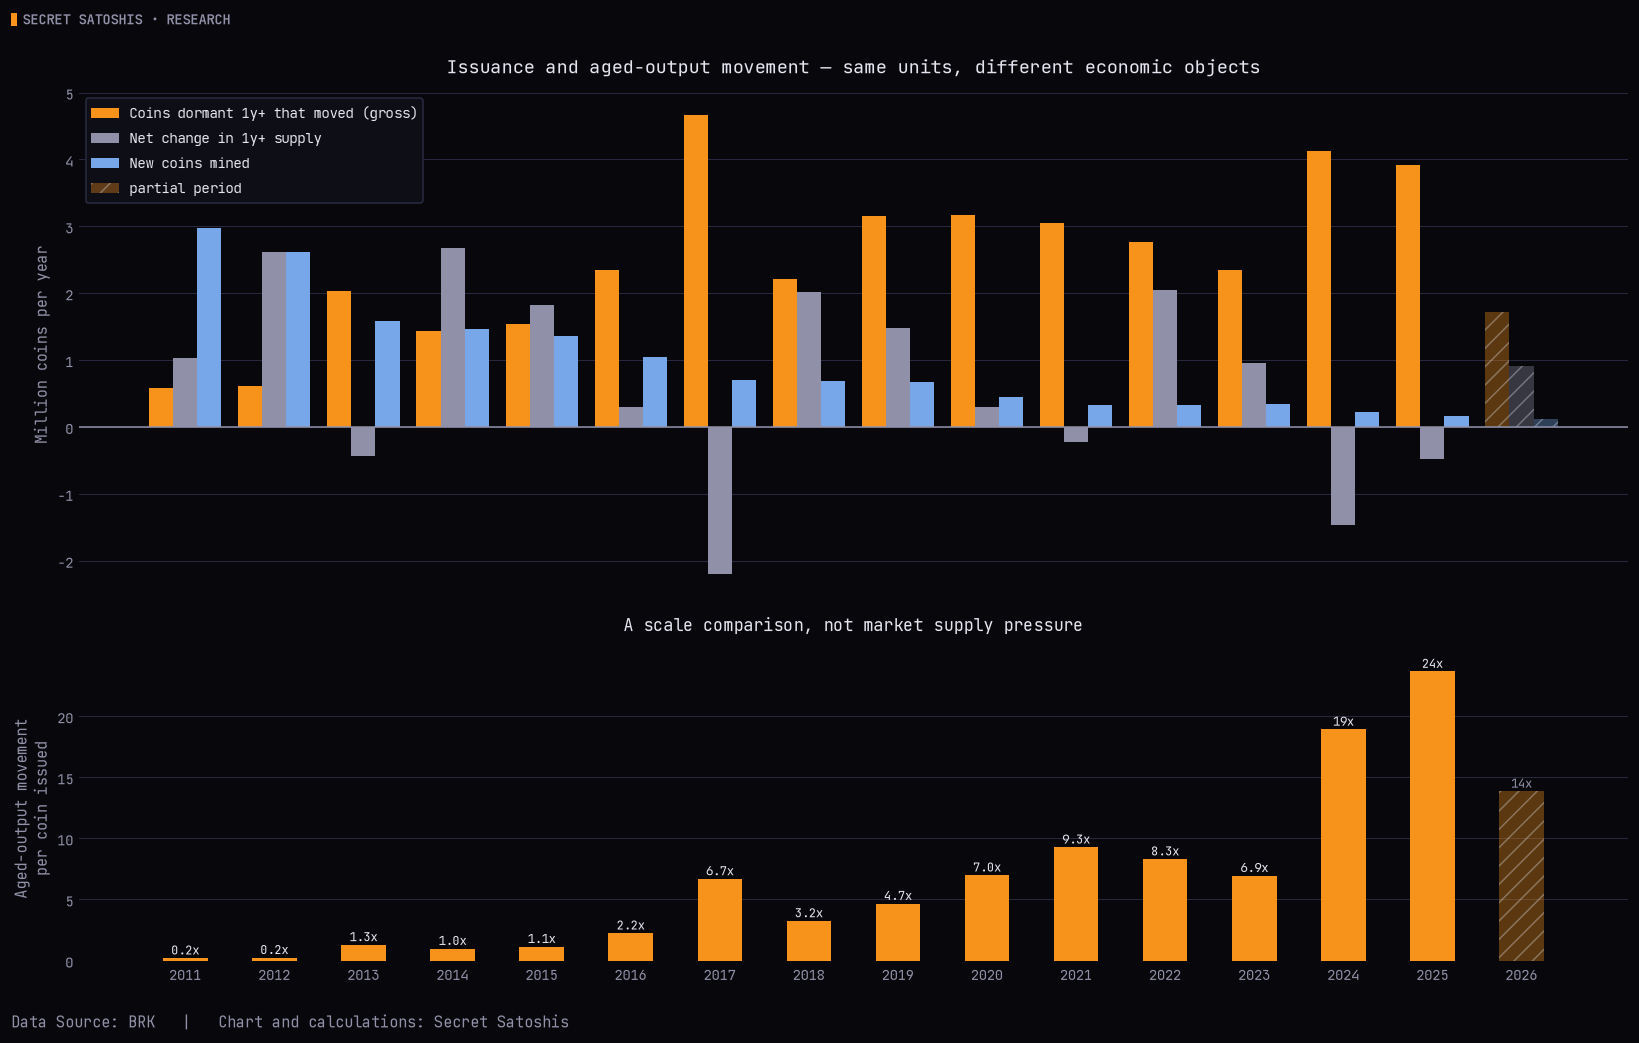

In 2025:
  miners created                 165,881 coins
  coins dormant 1y+ moved      3,923,573 coins  (gross)
  net change in 1y+ supply      -481,891 coins
  gross movement per coin issued        24x
  coins maturing into 1y+          3,441,682 coins
  gross movement vs average 1y+ supply    32%

Gross movement per coin issued, recent complete years:
  2018     3.2x   net 1y+ change   +2,020,147
  2019     4.7x   net 1y+ change   +1,474,005
  2020     7.0x   net 1y+ change     +305,296
  2021     9.3x   net 1y+ change     -222,713
  2022     8.3x   net 1y+ change   +2,045,159
  2023     6.9x   net 1y+ change     +957,235
  2024    18.9x   net 1y+ change   -1,464,589
  2025    23.7x   net 1y+ change     -481,891


In [17]:
# Both sides off the full record, so the annual table matches the issuance
# figures quoted in section 1 rather than starting at the first market price.
history = raw.loc[:LAST_DAY]
annual_aged = history["utxos_over_1y_old_transfer_volume_daily"].resample("YE").sum(min_count=1)
annual_mined = history["subsidy_daily"].resample("YE").sum(min_count=1)
annual_net = history["utxos_over_1y_old_supply"].resample("YE").last().diff()

comp = pd.DataFrame({"Aged coins moved": annual_aged,
                     "Net change in 1y+ supply": annual_net,
                     "New coins mined": annual_mined})
# The ratio compares magnitudes in the same units, not equivalent economic flows.
# Issuance changes the stock; aged-output movement is gross UTXO turnover. The net
# figure is a change in the size of the dormant pool and is shown separately.
comp["Ratio"] = comp["Aged coins moved"] / comp["New coins mined"]
comp["complete"] = complete_periods(comp.index, "Y", first=history.index.min()).values
comp = comp[comp.index.year >= 2011]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9.5), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1.2]})
x = np.arange(len(comp))
full = comp["complete"].values
moved, net, mined = (comp["Aged coins moved"] / 1e6, comp["Net change in 1y+ supply"] / 1e6,
                     comp["New coins mined"] / 1e6)

ax1.bar(x[full] - .27, moved[full], width=.27, color=ORANGE,
        label="Coins dormant 1y+ that moved (gross)")
ax1.bar(x[full], net[full], width=.27, color=GREY,
        label="Net change in 1y+ supply")
ax1.bar(x[full] + .27, mined[full], width=.27, color=BLUE, label="New coins mined")
for off, series, color in ((-.27, moved, ORANGE), (0, net, GREY), (.27, mined, BLUE)):
    ax1.bar(x[~full] + off, series[~full], width=.27, color=color, alpha=.35, hatch="//",
            label="partial period" if off == -.27 else None)
ax1.axhline(0, color=GREY, linewidth=1)
ax1.set_xticks(x); ax1.set_xticklabels([d.year for d in comp.index], rotation=0)
ax1.set_ylabel("Million coins per year"); ax1.legend(fontsize=9)
ax1.set_title("Issuance and aged-output movement — same units, different economic objects", fontsize=12, pad=12)

ax2.bar(x[full], comp["Ratio"][full], width=.5, color=ORANGE)
ax2.bar(x[~full], comp["Ratio"][~full], width=.5, color=ORANGE, alpha=.35, hatch="//")
for xi, r, ok in zip(x, comp["Ratio"], full):
    ax2.annotate(f"{r:.1f}x" if r < 10 else f"{r:.0f}x",
                 (xi, r), ha="center", va="bottom", fontsize=8,
                 color=PRIMARY if ok else GREY)
ax2.set_xticks(x); ax2.set_xticklabels([d.year for d in comp.index])
ax2.set_ylabel("Aged-output movement\nper coin issued")
ax2.set_title("A scale comparison, not market supply pressure", fontsize=11)
finish(fig, sources=[BRK])

full_years = comp[comp["complete"]]
lastf = full_years.iloc[-1]
print(f"In {full_years.index[-1].year}:")
print(f"  miners created            {lastf['New coins mined']:>12,.0f} coins")
print(f"  coins dormant 1y+ moved   {lastf['Aged coins moved']:>12,.0f} coins  (gross)")
print(f"  net change in 1y+ supply  {lastf['Net change in 1y+ supply']:>+12,.0f} coins")
print(f"  gross movement per coin issued {lastf['Ratio']:>9,.0f}x")
matured = lastf["Aged coins moved"] + lastf["Net change in 1y+ supply"]
average_pool = history["utxos_over_1y_old_supply"][history.index.year == full_years.index[-1].year].mean()
print(f"  coins maturing into 1y+       {matured:>12,.0f} coins")
print(f"  gross movement vs average 1y+ supply {lastf['Aged coins moved'] / average_pool:>6.0%}")
print("\nGross movement per coin issued, recent complete years:")
for when, row in full_years.tail(8).iterrows():
    print(f"  {when.year}  {row['Ratio']:>6.1f}x   net 1y+ change {row['Net change in 1y+ supply']:>+12,.0f}")


### What the numbers say

The gross ratio sat near or below one through the early years, when issuance was still large and the stock of aged coins was small. It has climbed since — the output above lists recent complete years — partly because more dormant supply moved, and partly because issuance halved again.

The net bar is what separates years with similar gross numbers. The output above splits the latest complete year into coins that left the year-plus band and coins that matured into it: when the first exceeds the second, the pool drains — old UTXOs re-aging faster than the cohort is replenished. Heavy gross movement alone does not mean the pool shrank; in years where maturation kept pace, it grew. The result describes the age distribution, not sales.

One qualification carries over from section 2, and it is narrower than it is usually stated. The numerator counts coins leaving the year-old band, which is a fact about the chain: those outputs were consumed and their clocks reset. What it does not count is decisions. Spending is all-or-nothing at the level of an output, so moving five coins out of a thousand-coin output registers a thousand coins of movement — the protocol chose that size, not the holder. For scale, the output above also expresses that year's gross movement as a share of the average year-plus supply.

Whether any particular move was a sale, a wallet reorganization or a custodian rotating keys is not knowable from the chain. There are no owners in the protocol, only outputs. The comparison measures issuance and dormancy ending; neither side is a count of coins offered for sale.

**The protocol sets issuance. The chain reveals dormancy ending, not market availability.**

What was built, and what each piece answers:

| Measure | The question it answers |
|---|---|
| Age cohorts | How much supply has been sitting still, and for how long? |
| Coin-days destroyed | When coins do move, how much dormancy ended? |
| Realized price | What is the UTXO set's creation-price proxy? |
| Supply in profit | For how much supply is market price above the UTXO creation-price proxy? |
| UTXO split and realized prices | Do recently created and long-term outputs carry the same proxy? |
| The aging identity | Is a cohort growing because coins matured in, or because few aged outputs left it? |
| Net aging | Are old-output cohorts filling or draining? |
| Realized profit and loss | How are spent outputs repriced relative to creation? |
| Net aging vs gross movement | Is the old-output cohort shrinking despite gross turnover? |

None of these requires a forecast to be useful. They describe a market's supply structure as it stands, from data the chain publishes about itself.

**On the limitations, once more and plainly.** Aggregation reduces the influence of a single large transaction, but it does not remove structural custody migrations or prove that operational movement is stable through time. Multi-month trends are more robust descriptions of UTXO aging than single days, yet they remain on-chain turnover measures rather than direct measures of ownership transfer, sales or liquidity.

**Three more, worth stating rather than burying.** Some of the oldest supply is lost, not held: coins behind keys nobody has age into the deepest bands forever and never leave them, which flatters every measure of accumulation. Dormancy is not the same as availability. Custodial inventory that has sat untouched for a year sits in the year-plus cohort like any other coin, and it can be mobilised in a single block — stillness is evidence about the past, not a constraint on what happens next. And this notebook works entirely from age and cost basis; it does not use entity labels or exchange balances, which are the other standard route to the same question and depend on a labelling process the chain does not publish.

---

## Data sources and terms

Every chart in this notebook is built from one source, credited in its footer.

| Data | Source | Terms |
|---|---|---|
| Supply, issuance, age cohorts, holder groups, realized price and P/L, coin-days destroyed, price | [BRK](https://bitview.space) (Bitcoin Research Kit), computed from the public blockchain, published in the [Bitcoin Report Library](https://github.com/SecretSatoshis/Bitcoin-Report-Library) | MIT-licensed open-source software; the data describes the public chain |

Daily flows are first differences of BRK's cumulative series, and every ratio, band and aggregate is calculated in this notebook.